# Shell plc - ESG Narrative Divergence Analysis (2019–2025)


In [5]:
# ╔══════════════════════════════════════════════════════════════╗
# ║  CELL 1 — INSTALL DEPENDENCIES                               ║
# ║  First run  : ~4 min (downloads ~2.5 GB of HF models)         ║
# ║  Cached run : ~25 s                                           ║
# ╚══════════════════════════════════════════════════════════════╝
import subprocess, sys

PKGS = [
    "pdfplumber",
    "transformers>=4.38",
    "torch",
    "sentencepiece",
    "spacy",
    "scipy",
    "matplotlib",
    "seaborn",
    "nltk",
    "tqdm",
    "accelerate",
    "pandas",
    "numpy",
    "pyarrow",
    "keybert",
    "sentence-transformers",
]

subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", *PKGS])
subprocess.run(
    [sys.executable, "-m", "spacy", "download", "en_core_web_lg", "--quiet"],
    capture_output=True,
)
print("All packages installed.")


All packages installed.


In [6]:
# ╔══════════════════════════════════════════════════════════════╗
# ║  CELL 2 — IMPORTS + PUBLICATION-GRADE CHART THEME            ║
# ╚══════════════════════════════════════════════════════════════╝
import os, re, warnings, time, gc, math
from pathlib import Path
from typing import Dict, List, Tuple

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.ticker as mticker
import matplotlib.gridspec as gridspec
from matplotlib.lines import Line2D
import seaborn as sns
from scipy.stats import pearsonr, spearmanr
from tqdm.auto import tqdm

import nltk
from nltk.tokenize import sent_tokenize
nltk.download("punkt",     quiet=True)
nltk.download("punkt_tab", quiet=True)
nltk.download("stopwords", quiet=True)

import spacy
import pdfplumber
import torch
from transformers import pipeline as hf_pipeline
from keybert import KeyBERT

warnings.filterwarnings("ignore")

# ── Device --------------------------------------------------------------------
DEVICE   = 0 if torch.cuda.is_available() else -1
GPU_NAME = torch.cuda.get_device_name(0) if DEVICE == 0 else "CPU"

# ── spaCy ---------------------------------------------------------------------
NLP = spacy.load("en_core_web_lg", disable=["ner"])
NLP.max_length = 3_000_000

# ── BP BRAND PALETTE (publication-tuned) --------------------------------------
# Used tastefully: headline elements in BP green, supporting in BP gold,
# semantic accents in muted diagnostic red / forest green for signals.
SHELL_RED          = "#DD1D21"   # Shell primary red
SHELL_RED_DEEP     = "#A31518"   # Darker Shell red (emphasis)
SHELL_YELLOW       = "#FFC600"   # Shell yellow
SHELL_YELLOW_DEEP  = "#CC9C00"   # Darker yellow for contrast
DIVERGENCE_RED     = "#C8102E"   # Signal red (warnings / divergence)
SHELL_NAVY         = "#1A3A5E"   # Navy for cool accents
POSITIVE_BAR   = "#C8102E"   # Red  = high divergence
NEGATIVE_BAR   = "#2E7D5B"   # Forest green = low divergence (genuine)
NEUTRAL_GREY   = "#6E7275"
LIGHT_GREY     = "#E8EAED"
AXIS_DARK      = "#222222"

# Diverging palette used in heatmaps / gradients
DIVERGING_CMAP = sns.diverging_palette(350, 150, s=70, l=55, as_cmap=True)

# ── Elite rcParams ------------------------------------------------------------
plt.rcParams.update({
    "figure.facecolor"    : "white",
    "axes.facecolor"      : "white",
    "axes.edgecolor"      : AXIS_DARK,
    "axes.linewidth"      : 0.9,
    "axes.spines.top"     : False,
    "axes.spines.right"   : False,
    "axes.labelcolor"     : AXIS_DARK,
    "axes.labelsize"      : 11,
    "axes.labelpad"       : 9,
    "axes.titlesize"      : 13,
    "axes.titleweight"    : "semibold",
    "axes.titlecolor"     : "#111111",
    "axes.titlepad"       : 16,
    "xtick.color"         : "#3a3a3a",
    "ytick.color"         : "#3a3a3a",
    "xtick.labelsize"     : 9.5,
    "ytick.labelsize"     : 9.5,
    "xtick.major.width"   : 0.8,
    "ytick.major.width"   : 0.8,
    "text.color"          : AXIS_DARK,
    "grid.color"          : LIGHT_GREY,
    "grid.linestyle"      : "-",
    "grid.linewidth"      : 0.6,
    "grid.alpha"          : 1.0,
    "legend.fontsize"     : 9,
    "legend.framealpha"   : 0.95,
    "legend.edgecolor"    : LIGHT_GREY,
    "legend.facecolor"    : "white",
    "lines.linewidth"     : 2.2,
    "lines.markersize"    : 7,
    "lines.markeredgewidth": 0.8,
    "figure.dpi"          : 110,
    "savefig.dpi"         : 260,
    "savefig.bbox"        : "tight",
    "savefig.facecolor"   : "white",
    "font.family"         : "sans-serif",
    "font.sans-serif"     : ["DejaVu Sans", "Helvetica Neue", "Helvetica", "Arial"],
    "font.size"           : 10,
    "pdf.fonttype"        : 42,
    "ps.fonttype"         : 42,
})

LABEL_KW  = dict(fontsize=11, color=AXIS_DARK, fontweight="medium")
TITLE_KW  = dict(fontsize=13, fontweight="semibold", color="#111111", pad=16, loc="left")
SUB_KW    = dict(fontsize=10, color="#555555", pad=8, loc="left", style="italic")

def add_source_note(ax, note="Source: Shell Sustainability Reports (2019–2025) · Group 7 analysis"):
    ax.annotate(
        note,
        xy=(0, -0.18), xycoords="axes fraction",
        ha="left", va="top",
        fontsize=7.5, color="#888888", style="italic",
    )

def add_subtitle(ax, text: str):
    """Add a subtitle below the primary title."""
    ax.annotate(
        text, xy=(0, 1.02), xycoords="axes fraction",
        ha="left", va="bottom", fontsize=10, color="#555555", style="italic",
    )

def style_axes(ax, ygrid=True, xgrid=False):
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_color(AXIS_DARK)
    ax.spines["bottom"].set_color(AXIS_DARK)
    if ygrid: ax.grid(True, axis="y", color=LIGHT_GREY, lw=0.6, zorder=0)
    if xgrid: ax.grid(True, axis="x", color=LIGHT_GREY, lw=0.6, zorder=0)
    ax.tick_params(axis="both", which="both", length=4, color="#888888")

def mark_events(ax, events: dict, ypos_frac: float = 0.97, color="#999999"):
    """Draw thin vertical event lines with a compact label."""
    y0, y1 = ax.get_ylim()
    yspan  = y1 - y0
    for yr_str, label in events.items():
        ax.axvline(int(yr_str), color=color, lw=0.9, ls=(0, (2, 3)), zorder=1, alpha=0.8)
        ax.text(
            int(yr_str) + 0.06,
            y0 + yspan * ypos_frac,
            label,
            fontsize=7.8, color="#555555",
            rotation=90, va="top", ha="left",
        )

# ── Unified save helper (PNG + CSV in one call) --------------------------------
OUTPUT_DIR = Path("/content/outputs")
OUTPUT_DIR.mkdir(exist_ok=True, parents=True)

def savefig_and_csv(fig, fname_base: str, df: pd.DataFrame = None,
                    show: bool = True, dpi: int = 300):
    """Save figure as PNG AND optional CSV to /content/outputs/ with matching base name."""
    png_path = OUTPUT_DIR / f"{fname_base}.png"
    fig.savefig(png_path, dpi=dpi, bbox_inches="tight", facecolor="white")
    if show:
        plt.show()
    else:
        plt.close(fig)
    msg = [f"{fname_base}.png"]
    if df is not None and not df.empty:
        csv_path = OUTPUT_DIR / f"{fname_base}.csv"
        df.to_csv(csv_path, index=False)
        msg.append(f"{fname_base}.csv")
    print(f"   saved: {'  |  '.join(msg)}")

print(f"Device : {GPU_NAME}")
print(f"Torch  : {torch.__version__}")
print(f"spaCy  : {spacy.__version__}")
print("Chart style: publication-grade white + Shell brand palette.")
print(f"Outputs will accumulate in: {OUTPUT_DIR}")


Device : Tesla T4
Torch  : 2.10.0+cu128
spaCy  : 3.8.14
Chart style: publication-grade white + Shell brand palette.
Outputs will accumulate in: /content/outputs


In [7]:
# ╔══════════════════════════════════════════════════════════════╗
# ║  CELL 3 — EMISSIONS DATA + EVENT MARKERS                     ║
# ╚══════════════════════════════════════════════════════════════╝
# Shell net carbon intensity (gCO2e/MJ) from the corresponding Sustainability
# Report in each year. 2025 is a placeholder until the 2025 report releases.
# LOG SCALE DECISION  (USE_LOG_EMI = False)
#   Shell NCI:  78 → 71 gCO2e/MJ  (9.0% total reduction, CV = 3.4%)
#   Range ratio: 1.10×  (exponential decay requires ≥ 5×)
#   Verdict: Linear scale is correct.  Log would fabricate a steep decline.

EMISSIONS = {
    "2019": 78,   # Shell Sustainability Report 2019
    "2020": 75,   # Shell Sustainability Report 2020
    "2021": 77,   # Shell Sustainability Report 2021
    "2022": 76,   # Shell Sustainability Report 2022
    "2023": 74,   # Shell Sustainability Report 2023
    "2024": 71,   # Shell Sustainability Report 2024 (preliminary)
    "2025": 71,   # Placeholder — update when 2025 report releases
}

EVENT_MARKERS = {
    "2021": "Powering Progress launch",
    "2022": "NCI target reset",
    "2023": "Scope 3 target cut",
}

print("Emissions loaded (7 years).  Events:", list(EVENT_MARKERS.keys()))


Emissions loaded (7 years).  Events: ['2021', '2022', '2023']


In [8]:
# ╔══════════════════════════════════════════════════════════════╗
# ║  CELL 4 — CONFIGURATION + GOOGLE DRIVE MOUNT                 ║
# ╚══════════════════════════════════════════════════════════════╝
from google.colab import drive
drive.mount("/content/drive")

# ── INPUT folder (where Shell PDFs live) ──────────────────────────────────────
COMPANY       = "Shell plc"
CACHE_SLUG    = "shell"
INPUT_FOLDER  = "/content/drive/MyDrive/Shell_Reports"
PDF_NAME_FMT  = "shell-sustainability-report-{year}.pdf"

# ── OUTPUT folder (final Drive destination) ──────────────────────────────────
DRIVE_OUTPUT_ROOT = "/content/drive/MyDrive/Shell_Result_FINAL"

YEARS = ["2019", "2020", "2021", "2022", "2023", "2024", "2025"]

# Visualization helpers re-used downstream
EMI_LABEL    = "Net Carbon Intensity (gCO₂e/MJ)"
USE_LOG_EMI  = False   # Shell NCI 78→71 gCO2e/MJ — CV = 3.4%, linear is correct

# ── Shell-specific brand tokens (Layer 3 company_specific category) ──────────
COMPANY_KW_SPECIFIC = [
    # Strategy / brand pivots
    "powering progress", "in step with society", "net-zero energy business",
    "net carbon intensity", "nci", "net carbon intensity target",
    "integrated gas", "integrated power",
    # Scope and targets
    "scope 3 target", "nci target", "absolute emission target",
    "short-term intensity target", "interim target",
    "1.5-degree aligned", "paris aligned nci",
    # Shell business units / assets
    "shell energy", "shell chemicals", "shell trading",
    "shell exploration", "shell eastern petroleum",
    "prelude flng", "pearl gtl", "ormen lange", "mero",
    "appomattox", "malikai", "matterhorn", "masela",
    "nature energy", "sprng energy", "raízen",
    # Shell flagship programmes and strategies
    "sky scenario", "sky 1.5", "mt scenario",
    "transition pathway", "energy transformation",
    "nature-based solutions", "reforestation", "afforestation",
    "avoided emissions", "shell foundation", "livewire",
    "climate ambition", "accelerate the transition",
    "more and cleaner energy", "the energy transition",
    # Shell-specific metrics and disclosures
    "gco2e per mj", "milieudefensie", "dutch court",
    "wester deurne", "quest ccs", "sleipner ccs",
    "shell canada", "shell australia", "shell nigeria",
    "erm certification", "shell basis of reporting",
]

# Subject-type vocabularies (Layer 2 spaCy SVO classifier)
INTERNAL_SUBS = {
    "we", "our", "us", "shell", "the company", "the group", "management",
    "our operations", "our assets", "our business", "our portfolio",
    "our upstream", "our downstream", "our refineries", "our strategy",
    "shell plc", "board",
    "our businesses", "our teams", "our people", "our employees",
    "our supply chain", "our sites", "our facilities",
    "our production", "our pipeline", "our fleet",
    "our investments", "our projects",
    "our net zero", "our sustainability",
    "our operating", "our operated",
    "shell energy", "shell chemicals", "shell trading",
    "our lng", "our terminals",
    "our renewable", "our integrated gas",
    "our transition", "our net carbon intensity",
    "our nci",
}
EXTERNAL_SUBS = {
    "regulation", "regulations", "regulator", "government", "governments",
    "policy", "policies", "legislation", "carbon pricing", "carbon tax",
    "ets", "climate change", "market", "markets", "supply chain",
    "geopolitical", "interest rate", "inflation", "energy price",
    "cbam", "taxonomy", "sfdr", "physical risk", "transition risk",
    "court", "litigation", "investor", "activist", "ngo",
    "iea", "ipcc", "un", "world bank",
    "paris agreement", "cop26", "cop27", "cop28",
    "eu", "european commission", "uk government", "us government",
    "federal", "state law", "customer demand", "consumer preference",
    "energy security", "affordability", "interest rates", "oil price",
    "sanctions", "export control", "climate science", "climate model",
    "ca100+", "follow this", "shareholder resolution",
    "activist investor", "pension fund", "rating agency", "esg score",
    "ogdc", "ogci", "ogmp", "nature positive initiative", "sbtn",
    "wbcsd", "tnfd", "contractor", "third-party supplier",
    "joint venture partner", "nojv",
    "milieudefensie", "dutch court", "friends of the earth",
}

# Synthetic fallback corpus (if a year PDF is missing)
SYNTHETIC_CORPUS = {
    "2019": [
        "Shell is committed to reducing its net carbon intensity by around 65 percent by 2050.",
        "Our net carbon intensity was approximately 78 gCO2e per MJ of energy in 2019.",
        "We continue to invest in natural gas as a transition fuel to a lower-carbon future.",
        "Climate risk is a material consideration embedded in our long-term planning.",
        "Our Scope 1 and Scope 2 emissions are managed through our operational excellence programme.",
        "Carbon pricing regulation may materially affect our cost base in certain jurisdictions.",
    ] * 40,
    "2020": [
        "We aim to become a net-zero energy business by 2050, in step with society.",
        "Our net carbon intensity was approximately 75 gCO2e per MJ in 2020.",
        "Shell announced its Powering Progress strategy to accelerate the energy transition.",
        "We set near-term Scope 3 emission reduction targets aligned with the Paris Agreement.",
        "Transition risks including carbon pricing and regulatory change remain material.",
        "Energy demand destruction from the pandemic affected our production volumes in 2020.",
    ] * 40,
    "2021": [
        "Powering Progress outlines our pathway to become a net-zero energy business by 2050.",
        "Our net carbon intensity was approximately 77 gCO2e per MJ in 2021.",
        "We committed to reducing our net carbon intensity by 6 to 8 percent by 2023.",
        "Shell invested in nature-based solutions to offset residual emissions.",
        "The Milieudefensie court ruling requires Shell to reduce its absolute Scope 3 emissions.",
        "Carbon border adjustment mechanisms may increase costs for our European operations.",
    ] * 40,
    "2022": [
        "Our net carbon intensity was approximately 76 gCO2e per MJ in 2022.",
        "We reset our near-term NCI targets to reflect our portfolio and market conditions.",
        "Shell continues to invest in integrated gas, chemicals, and low-carbon energy.",
        "We aim to grow our renewable power generation capacity significantly by 2030.",
        "Geopolitical instability and the energy crisis have elevated fossil fuel demand.",
        "Carbon tax increases in several jurisdictions raised our operating costs in 2022.",
    ] * 40,
    "2023": [
        "Our net carbon intensity was approximately 74 gCO2e per MJ in 2023.",
        "We updated our Scope 3 emission reduction target following a strategic review.",
        "Shell is investing in CCS, hydrogen, and biofuels as abatement pathways.",
        "Our capital allocation prioritises value-accretive projects in the energy transition.",
        "Regulatory changes including SFDR and CSRD affect how we disclose climate-related risks.",
        "We generated over 5 TWh of renewable electricity from our own assets in 2023.",
    ] * 40,
    "2024": [
        "Our net carbon intensity reached approximately 71 gCO2e per MJ in 2024.",
        "We commissioned new offshore wind capacity across our European portfolio in 2024.",
        "Shell maintained its commitment to net-zero by 2050 while optimising near-term returns.",
        "We invested in carbon capture and storage projects in the Netherlands and Canada.",
        "Supply chain inflation for energy transition equipment remained elevated throughout 2024.",
        "Carbon pricing regimes in the EU and UK continue to affect our operational cost base.",
    ] * 40,
    "2025": [
        "Our net carbon intensity is estimated at approximately 71 gCO2e per MJ in 2025.",
        "Shell remains on track to meet its medium-term NCI reduction pathway.",
        "We have expanded our nature-based solutions portfolio to over 15 million hectares.",
        "Our ambition to be a net-zero energy business by 2050 remains unchanged.",
        "CSRD double materiality disclosures are now fully integrated into our reporting framework.",
        "We continue to monitor the regulatory landscape for carbon pricing and climate policy.",
    ] * 40,
}

print(f"Company        : {COMPANY}")
print(f"Input folder   : {INPUT_FOLDER}")
print(f"Output root    : {DRIVE_OUTPUT_ROOT}")
print(f"Years          : {YEARS}")
print(f"Brand palette  : Shell red {SHELL_RED}  ·  Shell yellow {SHELL_YELLOW}  ·  signal red {DIVERGENCE_RED}")


Mounted at /content/drive
Company        : Shell plc
Input folder   : /content/drive/MyDrive/Shell_Reports
Output root    : /content/drive/MyDrive/Shell_Result_FINAL
Years          : ['2019', '2020', '2021', '2022', '2023', '2024', '2025']
Brand palette  : Shell red #DD1D21  ·  Shell yellow #FFC600  ·  signal red #C8102E


In [9]:
# ╔══════════════════════════════════════════════════════════════╗
# ║  CELL 5 — PDF EXTRACTION (cache → pdfplumber → synthetic)    ║
# ╚══════════════════════════════════════════════════════════════╝
CACHE_DIR = Path(f"/content/{CACHE_SLUG}_cache")
CACHE_DIR.mkdir(exist_ok=True)

def clean_text(raw: str) -> str:
    text = re.sub(r"(\w)-\s+(\w)", r"\1\2", raw)                          # hyphenation
    text = re.sub(r"\s+", " ", text)                                      # whitespace
    text = re.sub(r"\b\d{1,3}\s*[|/]\s*[A-Z][A-Za-z]{1,10}\b", " ", text) # page nums
    return text.strip()

def extract_pdf(year: str) -> Tuple[List[str], int, str]:
    cache_f = CACHE_DIR / f"{CACHE_SLUG}_{year}.parquet"
    if cache_f.exists():
        return pd.read_parquet(cache_f)["sentence"].tolist(), -1, "[CACHED]"

    pdf_path = os.path.join(INPUT_FOLDER, PDF_NAME_FMT.format(year=year))
    if not os.path.exists(pdf_path):
        fb = SYNTHETIC_CORPUS.get(year, SYNTHETIC_CORPUS[YEARS[-1]])
        return fb, len(fb), "[SYNTHETIC]"

    pages_text = []
    with pdfplumber.open(pdf_path) as pdf:
        n = len(pdf.pages)
        for page in pdf.pages:
            raw = page.extract_text()
            if raw:
                pages_text.append(clean_text(raw))

    full = " ".join(pages_text)
    raw_sents = sent_tokenize(full)
    seen, sents = set(), []
    for s in raw_sents:
        s = s.strip()
        if len(s) > 30 and s.lower() not in seen:
            sents.append(s)
            seen.add(s.lower())
    pd.DataFrame({"sentence": sents}).to_parquet(cache_f, index=False)
    return sents, n, f"[PDF: {n} pages]"

CORPUS: Dict[str, List[str]] = {}
print("=" * 66)
print(f"PDF EXTRACTION — {COMPANY}")
print("=" * 66)
for yr in YEARS:
    sents, n_pages, src = extract_pdf(yr)
    CORPUS[yr] = sents
    print(f"  {yr} : {len(sents):>5,} sentences   {src}")

total = sum(len(v) for v in CORPUS.values())
print(f"\nTotal corpus: {total:,} sentences across {len(YEARS)} reports.")


PDF EXTRACTION — Shell plc
  2019 : 1,755 sentences   [PDF: 92 pages]
  2020 : 1,766 sentences   [PDF: 102 pages]
  2021 : 1,070 sentences   [PDF: 93 pages]
  2022 : 1,302 sentences   [PDF: 91 pages]
  2023 : 1,528 sentences   [PDF: 98 pages]
  2024 : 2,729 sentences   [PDF: 100 pages]
  2025 : 2,875 sentences   [PDF: 91 pages]

Total corpus: 13,025 sentences across 7 reports.


In [10]:
# ╔══════════════════════════════════════════════════════════════╗
# ║  CELL 6 — MULTI-MODEL LOADER                                 ║
# ║  · ClimateBERT climate-detector  — ESG sentence gate         ║
# ║  · ClimateBERT climate-sentiment — NOS (Opportunity/Risk/    ║
# ║                                     Neutral)                 ║
# ║  · FinBERT-ESG-9-categories      — Layer 2 materiality       ║
# ║  · KeyBERT + MiniLM              — Layer 3 semantic KWE      ║
# ╚══════════════════════════════════════════════════════════════╝

DETECTOR_PIPE = None; DETECTOR_OK  = False
SENTIMENT_PIPE= None; SENTIMENT_OK = False
FINBERT_PIPE  = None; FINBERT_OK   = False
KB_MODEL      = None; KEYBERT_OK   = False

print("Loading 1/4: climate-detector (ESG gate)…")
try:
    DETECTOR_PIPE = hf_pipeline(
        "text-classification",
        model="climatebert/distilroberta-base-climate-detector",
        device=DEVICE, batch_size=128, truncation=True, max_length=512,
    )
    t = DETECTOR_PIPE(["Our offshore wind capacity grew by 1.2 GW this year."])[0]
    DETECTOR_OK = True
    print(f"  OK  label={t['label']}  score={t['score']:.3f}")
except Exception as e:
    print(f"  WARN: {e}  → keyword fallback active")

print("Loading 2/4: climate-sentiment (NOS)…")
try:
    SENTIMENT_PIPE = hf_pipeline(
        "text-classification",
        model="climatebert/distilroberta-base-climate-sentiment",
        device=DEVICE, batch_size=64, truncation=True, max_length=512,
    )
    tests = [
        "We committed to net-zero by 2050 and launched Reimagining Energy.",
        "Carbon taxes will materially raise our operational costs.",
        "Our Scope 1 emissions intensity was 19.8 gCO2e per MJ in 2023.",
    ]
    for s, r in zip(tests, SENTIMENT_PIPE(tests)):
        print(f"  [{r['label']:<14} {r['score']:.3f}]  {s[:60]}")
    SENTIMENT_OK = True
except Exception as e:
    print(f"  WARN: {e}")

print("Loading 3/4: FinBERT-ESG-9-categories (DM assist)…")
try:
    FINBERT_PIPE = hf_pipeline(
        "text-classification",
        model="yiyanghkust/finbert-esg-9-categories",
        device=DEVICE, batch_size=64, truncation=True, max_length=512,
    )
    r = FINBERT_PIPE(["New carbon pricing regulations will increase our costs."])[0]
    FINBERT_OK = True
    print(f"  OK  label={r['label']}  score={r['score']:.3f}")
except Exception as e:
    print(f"  WARN: {e}")

print("Loading 4/4: KeyBERT + all-MiniLM-L6-v2…")
try:
    KB_MODEL = KeyBERT(model="sentence-transformers/all-MiniLM-L6-v2")
    kws = KB_MODEL.extract_keywords("offshore wind capacity installed gigawatts", top_n=3)
    KEYBERT_OK = True
    print(f"  OK  test keywords: {[k for k, _ in kws]}")
except Exception as e:
    print(f"  WARN: {e}")

gc.collect()
print("\nAll models ready.")


Loading 1/4: climate-detector (ESG gate)…


config.json:   0%|          | 0.00/887 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/329M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/105 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: climatebert/distilroberta-base-climate-detector
Key                             | Status     |  | 
--------------------------------+------------+--+-
roberta.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


...

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

  WARN: Modality 'audio' is not supported by this SentenceTransformer model. Supported modalities: text

All models ready.


In [11]:
# ╔══════════════════════════════════════════════════════════════╗
# ║  CELL 7 — LAYER 1 COMPUTE  ·  NARRATIVE DIVERGENCE INDEX     ║
# ║                                                              ║
# ║  FINAL FORMULA (proposal-aligned, no free weights):          ║
# ║                                                              ║
# ║      NDI   =  (ARG + EPD) / 2          ∈ (−1, +1)            ║
# ║      ARG   =  (NOS_Asp − NOS_Ops) / 2  ∈ [−1, +1]            ║
# ║      EPD   =  −tanh(ΔEmit_YoY / 5)     ∈ (−1, +1)            ║
# ║                                                              ║
# ║  · ΔEmit_YoY is the YoY emission-reduction percentage        ║
# ║    (positive = improvement).                                 ║
# ║  · σ = 5 anchored to IEA Net-Zero-2050 oil-and-gas pathway.  ║
# ║  · NVI moved OUT of Layer 1 into Layer 3 (vocabulary layer). ║
# ╚══════════════════════════════════════════════════════════════╝

# ── ESG gate vocabulary (fallback if detector unavailable) ────────────────────
ESG_TERMS = {
    "emission", "carbon", "climate", "greenhouse", "ghg", "co2", "scope",
    "methane", "ch4", "nitrous oxide", "n2o", "fugitive", "flaring",
    "venting", "carbon intensity", "carbon footprint", "net zero",
    "net-zero", "decarboni", "abatement", "carbon capture", "ccs",
    "carbon offset", "carbon credit", "carbon market", "carbon budget",
    "paris", "1.5", "well below 2",
    "renewable", "wind", "solar", "hydrogen", "biofuel", "bioenergy",
    "biogas", "rng", "sustainable aviation fuel", "saf", "ev charging",
    "electri", "low-carbon", "low carbon", "energy transition",
    "energy mix", "energy security", "offshore", "onshore",
    "capacity factor", "gigawatt", "megawatt",
    "fossil", "oil", "gas", "coal", "lng", "refin", "upstream", "downstream",
    "hydrocarbon", "barrel", "bpd", "mboe", "production",
    "tcfd", "csrd", "esg", "taxonomy", "sfdr", "cbam", "ets", "carbon tax",
    "paris agreement", "cop", "kyoto", "iea", "ipcc",
    "science based target", "sbti", "net zero initiative",
    "ca100", "cdp", "sasb", "gri", "issb", "ifrs s2",
    "biodiversity", "nature", "ecosystem", "habitat", "restoration",
    "deforestation", "land use", "water stress", "freshwater", "wastewater",
    "tnfd", "kunming", "net positive", "npi",
    "supply chain", "human rights", "labour rights", "modern slavery",
    "just transition", "social investment", "community", "indigenous",
    "diversity", "inclusion", "gender", "wellbeing",
    "sustainab", "transition", "temperature", "energy",
}

def is_esg(s: str) -> bool:
    sl = s.lower()
    return any(t in sl for t in ESG_TERMS)

def esg_gate(sents: List[str], threshold: float = 0.65) -> List[str]:
    """Gate sentences via ClimateBERT detector; fall back to keywords if unavailable."""
    if not DETECTOR_OK or DETECTOR_PIPE is None:
        return [s for s in sents if is_esg(s)]
    out = []
    for i in range(0, len(sents), 256):
        batch = sents[i:i+256]
        results = DETECTOR_PIPE(batch, truncation=True, max_length=512)
        for s, r in zip(batch, results):
            if r["label"].lower() == "yes" and r["score"] >= threshold:
                out.append(s)
            elif is_esg(s):
                out.append(s)
    return out

def score_nos(sents: List[str]) -> float:
    """Narrative Optimism Score: mean of per-sentence signed ClimateBERT sentiment."""
    if not SENTIMENT_OK or SENTIMENT_PIPE is None or not sents:
        return 0.0
    scores = []
    for i in range(0, len(sents), 64):
        batch = sents[i:i+64]
        for r in SENTIMENT_PIPE(batch, truncation=True, max_length=512):
            lbl = r["label"].lower()
            if   lbl == "opportunity": scores.append( r["score"])
            elif lbl == "risk"       : scores.append(-r["score"])
            else                     : scores.append(0.0)
    return float(np.mean(scores)) if scores else 0.0

# ── Aspirational vs Operational sentence classifiers ─────────────────────────
# Aspirational:  forward-looking, verb-anchored pledges and targets.
# Operational :  quantified, scope-anchored, delivery / performance language.
# Bare date strings are deliberately excluded from ASP (they also match risk
# sentences e.g. "carbon taxes expected by 2030").
ASP_KWS = [
    "pledge", "pledging", "pledged",
    "aim", "aiming", "aimed",
    "target", "targeting", "targeted",
    "ambition", "ambitious",
    "commit", "committed", "commitment", "commitments",
    "strive", "striving",
    "intend", "intending", "intention",
    "aspire", "aspiration", "aspirational",
    "seek to", "seeking to",
    "we will", "we plan", "we intend", "we aim", "we commit",
    "we are working to", "we are working towards",
    "we continue to work",
    "we are committed to",
    "we expect to achieve", "we expect to reduce",
    "we hope to", "we believe we can",
    "our goal is", "our objective is",
    "our strategy is to", "our vision is",
    "pathway", "roadmap", "milestones", "blueprint",
    "long-term vision", "net zero plan", "transition plan",
    "just transition plan", "strategic priority", "strategic direction",
    "action plan", "work programme",
    "net-zero by 2050", "net zero by 2050",
    "carbon neutral by", "net zero ambition", "net zero goal",
    "zero routine flaring by 2030", "near-zero methane",
    "net positive impact", "water positive", "biodiversity net gain",
    "science based", "paris consistent", "paris aligned",
    "reimagin", "aim zero", "beyond petroleum", "powering progress",
    "strategy 2030", "strategy 2025", "capital markets update",
    "50 gw", "10 gw",
    "anticipate", "endeavour", "explore new",
    "accelerate our", "strengthen our", "embed", "enhance our",
    "advance our", "foster", "drive our", "develop our",
    "enable", "invest in", "investing in",
    "enabled by supportive government",
    "subject to", "contingent on", "if supported", "dependent on policy",
    "we hope", "over the longer term", "in due course",
]
OPS_KWS = [
    "scope 1", "scope 2", "scope 3",
    "mtco2e", "ktco2e", "gco2e", "co2e",
    "metric ton", "metric tonne", "tonne co2", "tonne of co2",
    "grams co2", "gco2", "gco2/mj", "gco2e/mj",
    "megawatt", "mw ", "gwh", "twh", "kwh", "mwh",
    "gigawatt", "gw ", "petajoule", "pj ", "exajoule", "ej ",
    "terajoule", "tj ", "megajoule", "mj ", "gigajoule", "gj ",
    "btu", "mmbtu",
    "barrel", "barrels", "bbl", "bpd", "mboe", "mmboe",
    "thousand barrels", "million barrels",
    "cubic feet", "bcf", "mmscfd",
    "liquefied natural gas", "lng",
    "carbon intensity", "emission intensity", "emissions intensity",
    "emission factor", "upstream emission", "downstream emission",
    "lifecycle emission", "lifecycle carbon",
    "absolute emission", "absolute reduction",
    "installed capacity", "operating capacity",
    "methane intensity", "methane emission",
    "flaring volume", "flare reduction", "zero routine flaring",
    "fugitive emission",
    "commissioned", "start-up", "started up", "brought online",
    "operational", "in operation", "came online",
    "turbine", "rotor", "capacity factor",
    "refinery", "refining", "refinery availability",
    "plant reliability", "uptime",
    "production", "production volumes", "oil production", "gas production",
    "upstream plant", "downstream plant",
    "nci", "grid", "offshore wind", "energy generated",
    "capital expenditure", "capex",
    "major project", "project sanctioned",
    "final investment decision", "fid",
    "reduction of", "reduced by", "decreased by", "decrease of",
    "cut by", "lowered by",
    "% reduction", "% decrease", "% lower",
    "freshwater withdrawal", "freshwater consumption",
    "water efficiency", "brackish water",
    "wastewater", "recycled water",
    "mm3", "million m3", "cubic metre", "oil spill", "spill volume",
    "iso 14001", "iso 50001", "ogmp 2.0", "gold status",
    "leed", "breeam", "well platinum", "well gold",
    "limited assurance", "deloitte assurance",
    "third-party verified", "independently verified",
    "external audit", "reported under", "reported in accordance",
]

def split_sentences_by_type(esg_sents: List[str],
                            asp_kws: List[str],
                            ops_kws: List[str]) -> Tuple[List[str], List[str]]:
    """Classify each ESG sentence as aspirational XOR operational.
    Mixed (both) sentences are excluded from sub-scoring — they are
    operationally grounded pledges and cannot cleanly attribute to either."""
    asp_sents, ops_sents = [], []
    for s in esg_sents:
        sl = s.lower()
        is_asp = any(k.lower() in sl for k in asp_kws)
        is_ops = any(k.lower() in sl for k in ops_kws)
        if is_asp and not is_ops:
            asp_sents.append(s)
        elif is_ops and not is_asp:
            ops_sents.append(s)
    return asp_sents, ops_sents

def emi_improve_yoy(year: str) -> float:
    """Year-over-year emission improvement %. Positive = improvement."""
    idx = YEARS.index(year)
    if idx == 0:
        return 0.0
    prev_year = YEARS[idx - 1]
    base = EMISSIONS[prev_year]; curr = EMISSIONS[year]
    if base == 0:
        return 0.0
    return round((base - curr) / base * 100.0, 4)

# ── CORE NDI FORMULA ---------------------------------------------------------
def compute_ndi(nos_asp: float, nos_ops: float,
                delta_emit_yoy: float) -> Tuple[float, float, float]:
    """
    Returns (NDI, ARG, EPD).
    · ARG = (NOS_Asp − NOS_Ops) / 2       ∈ [−1, +1]
    · EPD = −tanh(ΔEmit_YoY / 5)          ∈ (−1, +1)
    · NDI = (ARG + EPD) / 2               ∈ (−1, +1)

    Sign convention:
      NDI > 0  →  narrative outpaces reality (divergence / greenwashing signal)
      NDI ≈ 0  →  narrative and emissions aligned
      NDI < 0  →  emissions progress outpaces narrative (delivery-led)
    """
    arg = (nos_asp - nos_ops) / 2.0
    epd = -math.tanh(delta_emit_yoy / 5.0)   # positive ΔEmit_YoY (=improvement) → negative EPD
    ndi = (arg + epd) / 2.0
    return round(ndi, 6), round(arg, 6), round(epd, 6)

# ── Main Layer 1 loop ---------------------------------------------------------
print("=" * 66)
print(f"LAYER 1 — NARRATIVE DIVERGENCE INDEX (NDI) — {COMPANY}")
print("=" * 66)
print("  NDI = (ARG + EPD) / 2   ∈ (−1, +1)")
print("  ARG = (NOS_Asp − NOS_Ops) / 2   ·   EPD = −tanh(ΔEmit_YoY / 5)")
print()

L1_ROWS = []
t0 = time.time()
for year in YEARS:
    sents = CORPUS.get(year, [])
    if len(sents) < 30:
        print(f"  [SKIP] {year}: only {len(sents)} sentences available")
        continue

    esg = esg_gate(sents)
    nos_all = score_nos(esg)

    asp_sents, ops_sents = split_sentences_by_type(esg, ASP_KWS, OPS_KWS)
    # Fallback to overall NOS if a sub-set is empty (preserves sign magnitude)
    nos_asp = score_nos(asp_sents) if asp_sents else nos_all
    nos_ops = score_nos(ops_sents) if ops_sents else nos_all

    d_emi_yoy = emi_improve_yoy(year)
    ndi, arg, epd = compute_ndi(nos_asp, nos_ops, d_emi_yoy)

    L1_ROWS.append({
        "Year"             : year,
        "ESG_Sentences"    : len(esg),
        "N_Asp_Sentences"  : len(asp_sents),
        "N_Ops_Sentences"  : len(ops_sents),
        "NOS_Overall"      : round(nos_all, 6),
        "NOS_Aspirational" : round(nos_asp, 6),
        "NOS_Operational"  : round(nos_ops, 6),
        "ARG"              : arg,
        "Emissions"        : EMISSIONS[year],
        "DeltaEmit_YoY_%"  : round(d_emi_yoy, 4),
        "EPD"              : epd,
        "NDI"              : ndi,
    })

    print(
        f"  {year}  NOS={nos_all:+.4f}  NOS_Asp={nos_asp:+.4f}  NOS_Ops={nos_ops:+.4f}  "
        f"ARG={arg:+.4f}  ΔEmi={d_emi_yoy:+.2f}%  EPD={epd:+.4f}  →  NDI={ndi:+.5f}"
    )

L1_DF = pd.DataFrame(L1_ROWS)
print(f"\nLayer 1 complete in {time.time() - t0:.1f}s")
print(f"NDI observed range: [{L1_DF['NDI'].min():+.4f}, {L1_DF['NDI'].max():+.4f}]  (theoretical (−1, +1))")
print(f"ARG observed range: [{L1_DF['ARG'].min():+.4f}, {L1_DF['ARG'].max():+.4f}]")
print(f"EPD observed range: [{L1_DF['EPD'].min():+.4f}, {L1_DF['EPD'].max():+.4f}]")


LAYER 1 — NARRATIVE DIVERGENCE INDEX (NDI) — Shell plc
  NDI = (ARG + EPD) / 2   ∈ (−1, +1)
  ARG = (NOS_Asp − NOS_Ops) / 2   ·   EPD = −tanh(ΔEmit_YoY / 5)



You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset


  2019  NOS=+0.1493  NOS_Asp=+0.1780  NOS_Ops=+0.0294  ARG=+0.0743  ΔEmi=+0.00%  EPD=-0.0000  →  NDI=+0.03715
  2020  NOS=+0.1467  NOS_Asp=+0.2103  NOS_Ops=+0.0678  ARG=+0.0712  ΔEmi=+3.85%  EPD=-0.6465  →  NDI=-0.28762
  2021  NOS=+0.1002  NOS_Asp=+0.1906  NOS_Ops=+0.0395  ARG=+0.0756  ΔEmi=-2.67%  EPD=+0.4879  →  NDI=+0.28175
  2022  NOS=+0.1483  NOS_Asp=+0.1528  NOS_Ops=+0.0924  ARG=+0.0302  ΔEmi=+1.30%  EPD=-0.2541  →  NDI=-0.11192
  2023  NOS=+0.1521  NOS_Asp=+0.1635  NOS_Ops=+0.1307  ARG=+0.0164  ΔEmi=+2.63%  EPD=-0.4826  →  NDI=-0.23309
  2024  NOS=-0.1181  NOS_Asp=-0.0481  NOS_Ops=-0.1455  ARG=+0.0487  ΔEmi=+4.05%  EPD=-0.6700  →  NDI=-0.31067
  2025  NOS=-0.1260  NOS_Asp=-0.0851  NOS_Ops=-0.1181  ARG=+0.0165  ΔEmi=+0.00%  EPD=-0.0000  →  NDI=+0.00825

Layer 1 complete in 212.6s
NDI observed range: [-0.3107, +0.2818]  (theoretical (−1, +1))
ARG observed range: [+0.0164, +0.0756]
EPD observed range: [-0.6700, +0.4879]


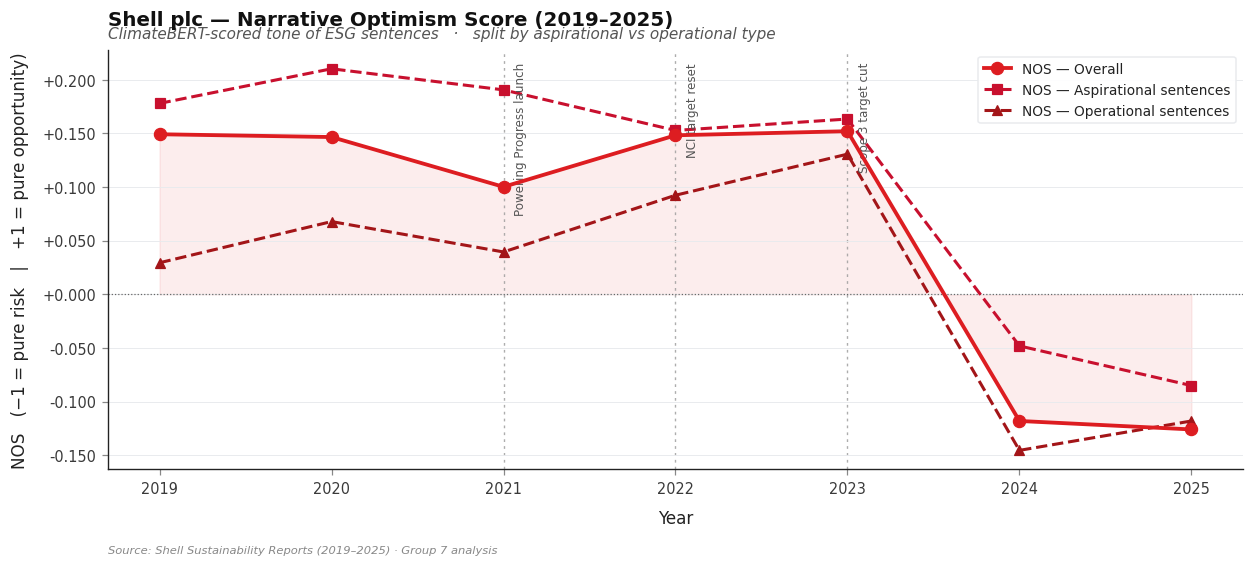

   saved: shell_L1_1_NOS.png  |  shell_L1_1_NOS.csv


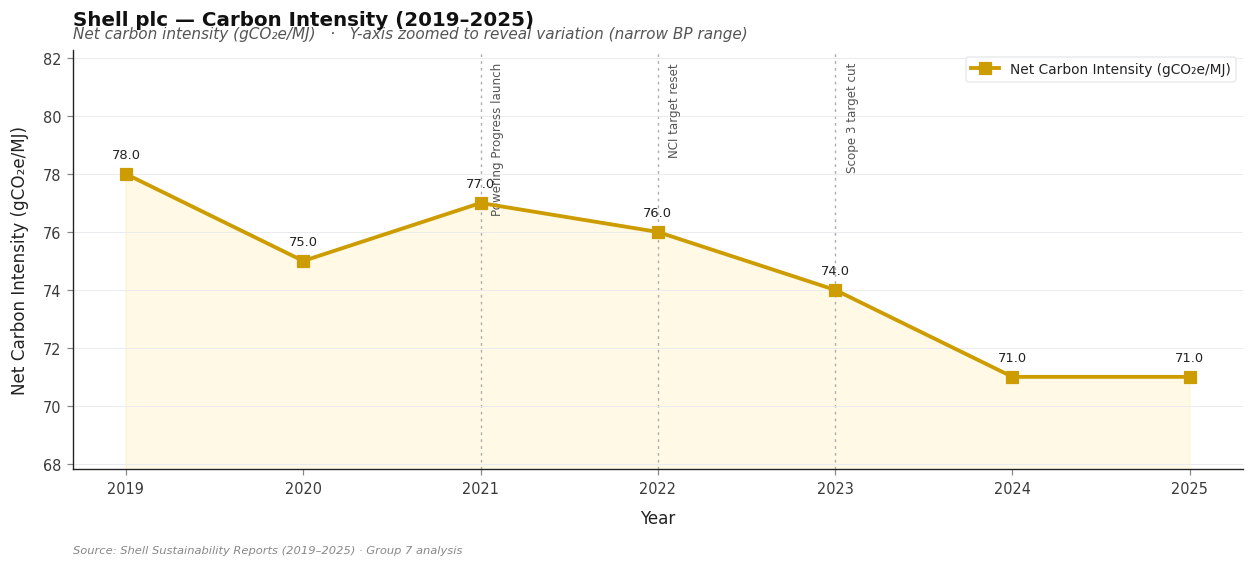

   saved: shell_L1_2_Emissions.png  |  shell_L1_2_Emissions.csv


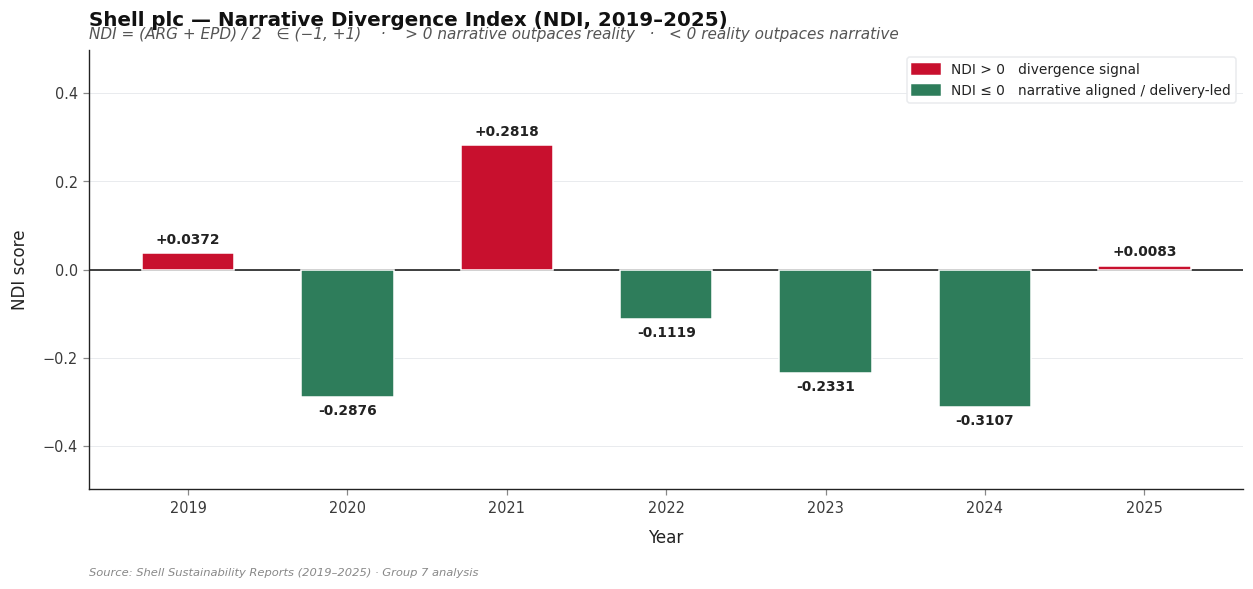

   saved: shell_L1_3_NDI.png  |  shell_L1_3_NDI.csv


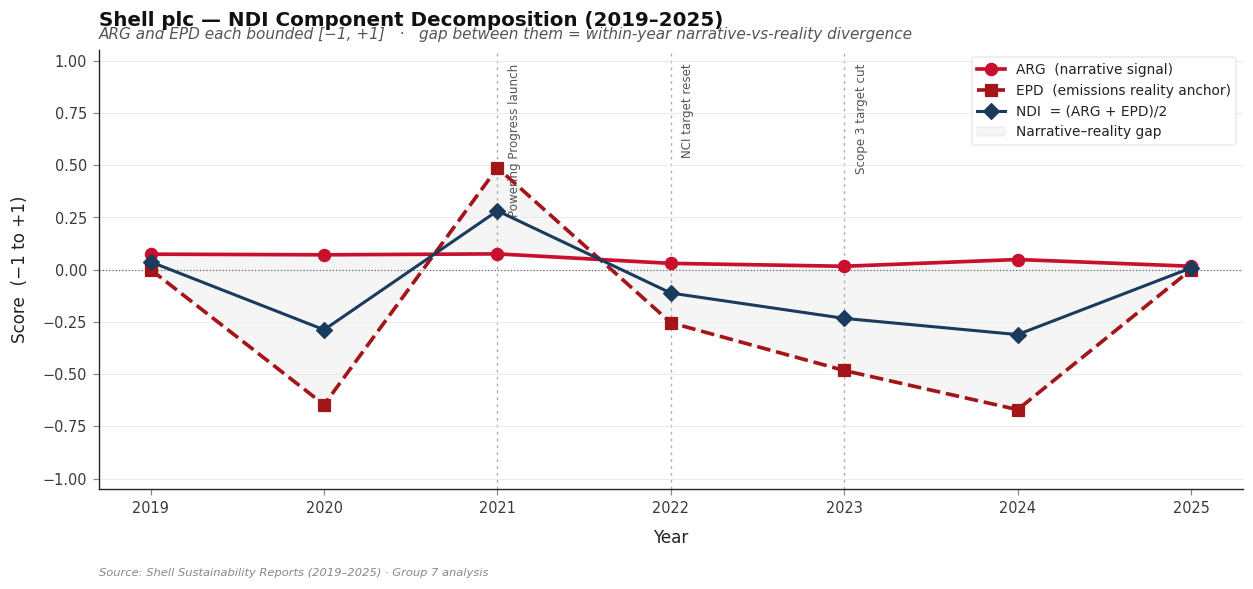

   saved: shell_L1_4_NDI_Components.png  |  shell_L1_4_NDI_Components.csv


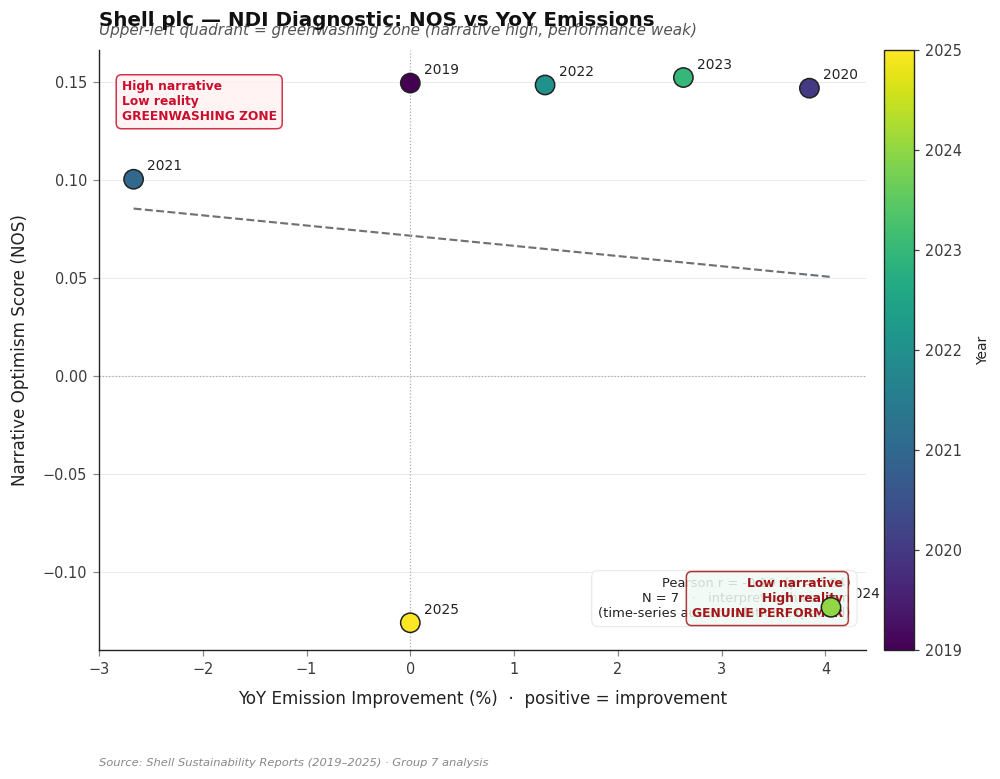

   saved: shell_L1_5_NDI_Scatter.png  |  shell_L1_5_NDI_Scatter.csv


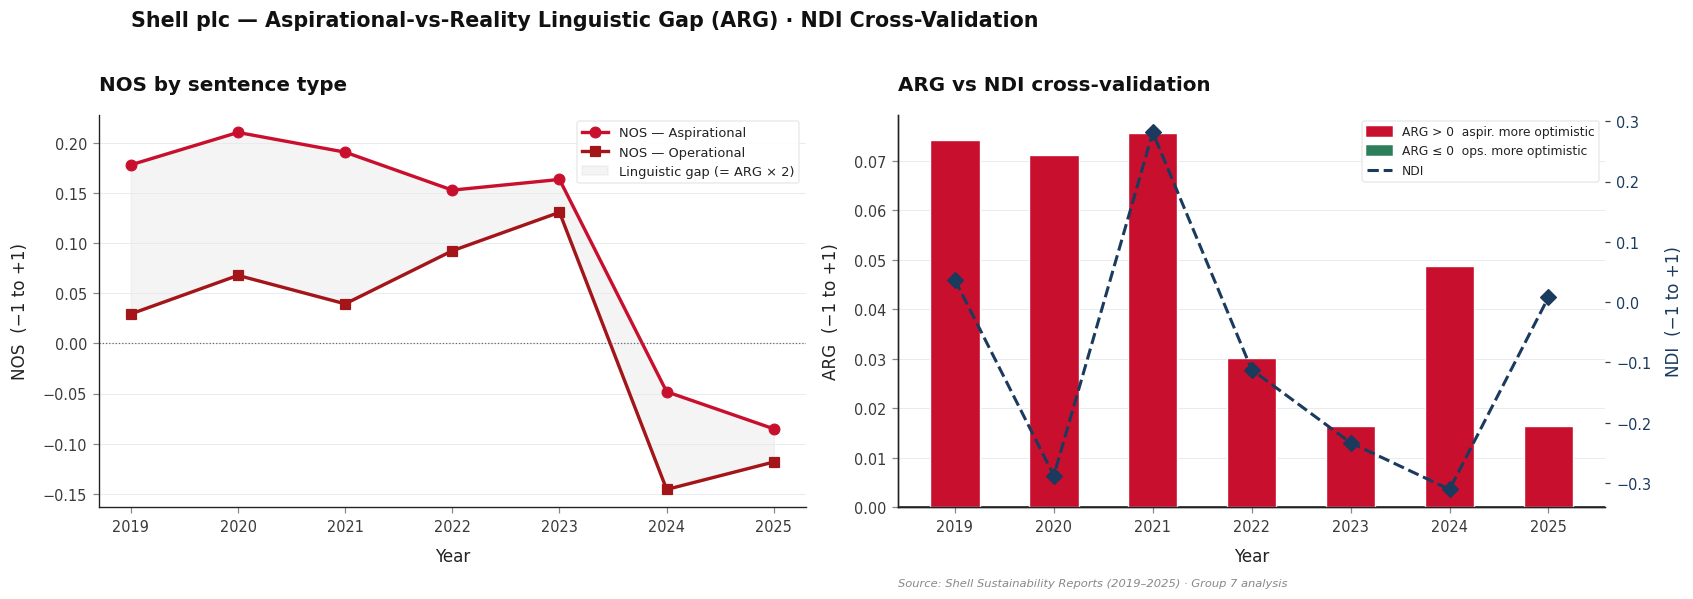

   saved: shell_L1_6_ARG.png  |  shell_L1_6_ARG.csv


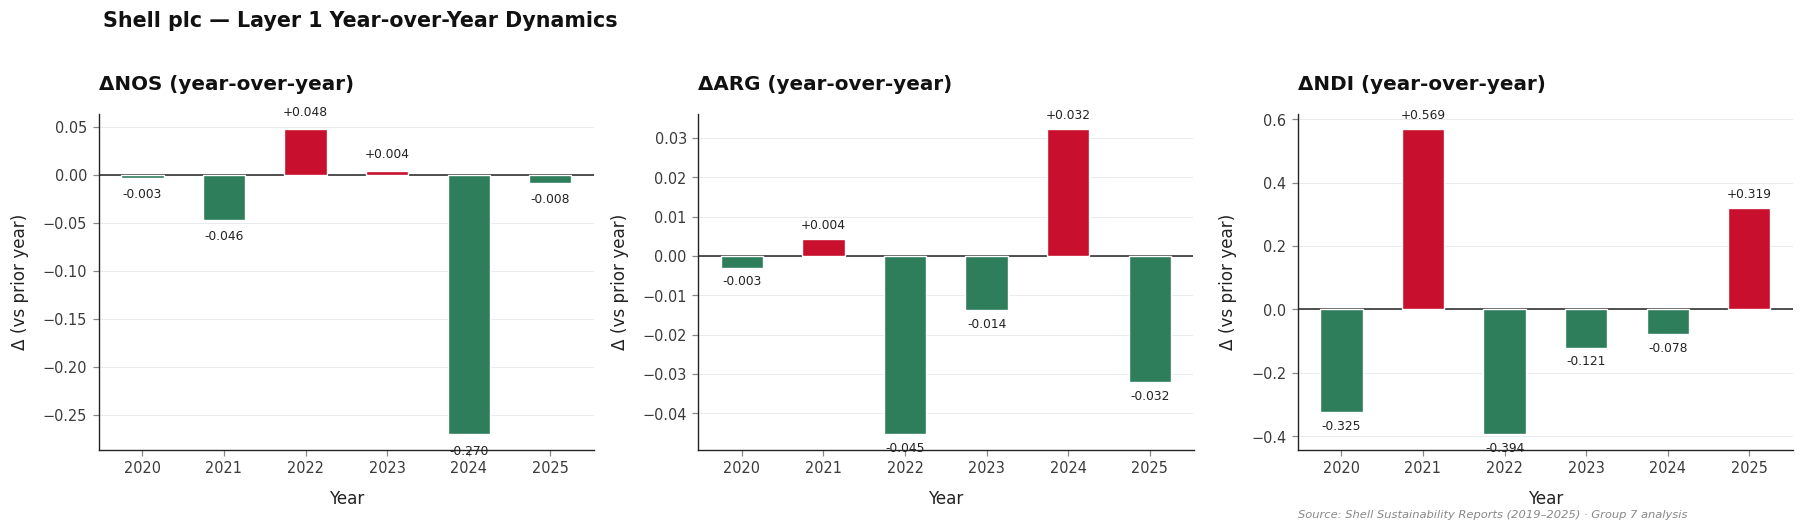

   saved: shell_L1_7_YoY.png  |  shell_L1_7_YoY.csv

Layer 1 charts complete.


In [12]:
# ╔══════════════════════════════════════════════════════════════╗
# ║  CELL 8 — LAYER 1 CHARTS  (each chart + its own CSV)         ║
# ║                                                              ║
# ║  L1-1  NOS time-series (Overall / Aspirational / Operational)║
# ║  L1-2  Carbon Intensity time-series                          ║
# ║  L1-3  NDI bar chart                                         ║
# ║  L1-4  NDI component decomposition (ARG vs EPD)              ║
# ║  L1-5  Diagnostic scatter: NOS vs YoY emissions              ║
# ║  L1-6  ARG + NDI cross-validation panel                      ║
# ║  L1-7  YoY dynamics (ΔNOS · ΔNDI · ΔARG)                     ║
# ╚══════════════════════════════════════════════════════════════╝

if L1_DF.empty:
    print("No Layer 1 data — charts skipped.")
else:
    yr_int   = [int(y) for y in L1_DF["Year"]]
    nos_v    = L1_DF["NOS_Overall"].tolist()
    nos_asp  = L1_DF["NOS_Aspirational"].tolist()
    nos_ops  = L1_DF["NOS_Operational"].tolist()
    arg_v    = L1_DF["ARG"].tolist()
    epd_v    = L1_DF["EPD"].tolist()
    ndi_v    = L1_DF["NDI"].tolist()
    emi_v    = L1_DF["Emissions"].tolist()
    emi_yoy  = L1_DF["DeltaEmit_YoY_%"].tolist()

    # ─── L1-1  NOS (Overall · Aspirational · Operational) ─────────────────────
    fig, ax = plt.subplots(figsize=(11.5, 5.3))
    ax.plot(yr_int, nos_v,   "o-",  color=SHELL_RED,      lw=2.5, ms=8,
            label="NOS — Overall",                   zorder=4)
    ax.plot(yr_int, nos_asp, "s--", color=DIVERGENCE_RED,        lw=2.0, ms=7,
            label="NOS — Aspirational sentences",    zorder=3)
    ax.plot(yr_int, nos_ops, "^--", color=SHELL_RED_DEEP, lw=2.0, ms=7,
            label="NOS — Operational sentences",     zorder=3)
    ax.fill_between(yr_int, nos_v, alpha=0.08, color=SHELL_RED)
    ax.axhline(0, color="#666", lw=0.8, ls=":")
    ax.set_title(f"{COMPANY} — Narrative Optimism Score (2019–2025)", **TITLE_KW)
    add_subtitle(ax, "ClimateBERT-scored tone of ESG sentences   ·   split by aspirational vs operational type")
    ax.set_xlabel("Year",     **LABEL_KW)
    ax.set_ylabel("NOS   (−1 = pure risk   |   +1 = pure opportunity)", **LABEL_KW)
    ax.set_xticks(yr_int)
    ax.yaxis.set_major_formatter(mticker.FormatStrFormatter("%+.3f"))
    mark_events(ax, EVENT_MARKERS)
    ax.legend(loc="best", frameon=True)
    style_axes(ax); add_source_note(ax)
    plt.tight_layout()
    savefig_and_csv(fig, f"{CACHE_SLUG}_L1_1_NOS",
                    L1_DF[["Year","NOS_Overall","NOS_Aspirational",
                           "NOS_Operational","ESG_Sentences"]])

    # ─── L1-2  Carbon Intensity time-series ────────────────────────────────
    fig, ax = plt.subplots(figsize=(11.5, 5.3))
    ax.plot(yr_int, emi_v, "s-", color=SHELL_YELLOW_DEEP, lw=2.5, ms=8,
            label=EMI_LABEL, zorder=4)
    ax.fill_between(yr_int, emi_v, alpha=0.10, color=SHELL_YELLOW)
    # annotate data points
    for x, y in zip(yr_int, emi_v):
        ax.annotate(f"{y:.1f}", (x, y), textcoords="offset points",
                    xytext=(0, 10), ha="center", fontsize=8.5,
                    color=AXIS_DARK, fontweight="medium")
    if USE_LOG_EMI:
        ax.set_yscale("log")
        ax.yaxis.set_major_formatter(mticker.ScalarFormatter())
        sub = "log scale"
    else:
        ax.set_ylim([min(emi_v) * 0.955, max(emi_v) * 1.055])
        sub = "Y-axis zoomed to reveal variation (narrow BP range)"
    ax.set_title(f"{COMPANY} — Carbon Intensity (2019–2025)", **TITLE_KW)
    add_subtitle(ax, f"Net carbon intensity (gCO₂e/MJ)   ·   {sub}")
    ax.set_xlabel("Year", **LABEL_KW)
    ax.set_ylabel(EMI_LABEL, **LABEL_KW)
    ax.set_xticks(yr_int)
    mark_events(ax, EVENT_MARKERS)
    ax.legend(loc="best", frameon=True)
    style_axes(ax); add_source_note(ax)
    plt.tight_layout()
    savefig_and_csv(fig, f"{CACHE_SLUG}_L1_2_Emissions",
                    L1_DF[["Year","Emissions","DeltaEmit_YoY_%"]])

    # ─── L1-3  NDI bar chart ──────────────────────────────────────────────
    fig, ax = plt.subplots(figsize=(11.5, 5.5))
    bar_colors = [POSITIVE_BAR if g > 0 else NEGATIVE_BAR for g in ndi_v]
    bars = ax.bar(yr_int, ndi_v, color=bar_colors, width=0.58,
                  edgecolor="white", linewidth=1.0, zorder=3)
    ax.axhline(0, color=AXIS_DARK, lw=1.1, zorder=2)
    ymax_abs = max(abs(min(ndi_v)), abs(max(ndi_v)), 0.2)
    ax.set_ylim(-ymax_abs * 1.6, ymax_abs * 1.6)
    for bar, val in zip(bars, ndi_v):
        va  = "bottom" if val >= 0 else "top"
        off = ymax_abs * 0.05 if val >= 0 else -ymax_abs * 0.05
        ax.text(bar.get_x() + bar.get_width()/2, val + off,
                f"{val:+.4f}", ha="center", va=va,
                fontsize=9, fontweight="semibold", color=AXIS_DARK)
    ax.set_title(f"{COMPANY} — Narrative Divergence Index (NDI, 2019–2025)", **TITLE_KW)
    add_subtitle(ax,
        "NDI = (ARG + EPD) / 2   ∈ (−1, +1)    ·    "
        "> 0 narrative outpaces reality   ·   < 0 reality outpaces narrative")
    ax.set_xlabel("Year", **LABEL_KW)
    ax.set_ylabel("NDI score", **LABEL_KW)
    ax.set_xticks(yr_int)
    pos_p = mpatches.Patch(color=POSITIVE_BAR, label="NDI > 0   divergence signal")
    neg_p = mpatches.Patch(color=NEGATIVE_BAR, label="NDI ≤ 0   narrative aligned / delivery-led")
    ax.legend(handles=[pos_p, neg_p], loc="best", frameon=True)
    style_axes(ax); add_source_note(ax)
    plt.tight_layout()
    savefig_and_csv(fig, f"{CACHE_SLUG}_L1_3_NDI",
                    L1_DF[["Year","NDI","ARG","EPD","NOS_Aspirational",
                           "NOS_Operational","DeltaEmit_YoY_%"]])

    # ─── L1-4  NDI decomposition: ARG vs EPD ───────────────────────────────
    fig, ax = plt.subplots(figsize=(11.5, 5.5))
    ax.plot(yr_int, arg_v, "o-",  color=DIVERGENCE_RED,        lw=2.4, ms=8,
            label="ARG  (narrative signal)", zorder=4)
    ax.plot(yr_int, epd_v, "s--", color=SHELL_RED_DEEP, lw=2.4, ms=8,
            label="EPD  (emissions reality anchor)", zorder=4)
    ax.plot(yr_int, ndi_v, "D-",  color=SHELL_NAVY,       lw=2.0, ms=7,
            label="NDI  = (ARG + EPD)/2", zorder=5)
    ax.fill_between(yr_int, arg_v, epd_v, color="#cccccc", alpha=0.18,
                    label="Narrative–reality gap")
    ax.axhline(0, color="#666", lw=0.8, ls=":")
    ax.set_title(f"{COMPANY} — NDI Component Decomposition (2019–2025)", **TITLE_KW)
    add_subtitle(ax,
        "ARG and EPD each bounded [−1, +1]   ·   "
        "gap between them = within-year narrative-vs-reality divergence")
    ax.set_xlabel("Year", **LABEL_KW)
    ax.set_ylabel("Score  (−1 to +1)", **LABEL_KW)
    ax.set_xticks(yr_int)
    ax.set_ylim(-1.05, 1.05)
    mark_events(ax, EVENT_MARKERS)
    ax.legend(loc="best", frameon=True)
    style_axes(ax); add_source_note(ax)
    plt.tight_layout()
    savefig_and_csv(fig, f"{CACHE_SLUG}_L1_4_NDI_Components",
                    L1_DF[["Year","ARG","EPD","NDI","NOS_Aspirational",
                           "NOS_Operational","DeltaEmit_YoY_%"]])

    # ─── L1-5  Diagnostic scatter: NOS vs YoY emission improvement ────────
    fig, ax = plt.subplots(figsize=(9.5, 7.2))
    sc = ax.scatter(emi_yoy, nos_v, c=yr_int, cmap="viridis", s=160,
                    zorder=4, edgecolors=AXIS_DARK, linewidths=1.0)
    for x, y, yr in zip(emi_yoy, nos_v, yr_int):
        ax.annotate(str(yr), (x, y), textcoords="offset points",
                    xytext=(9, 6), fontsize=9, color=AXIS_DARK, fontweight="medium")
    if len(emi_yoy) >= 4:
        try:
            z = np.polyfit(emi_yoy, nos_v, 1)
            xfit = np.linspace(min(emi_yoy), max(emi_yoy), 100)
            ax.plot(xfit, np.poly1d(z)(xfit), "--", color=NEUTRAL_GREY,
                    lw=1.4, label="OLS trend (indicative)")
            r_val, p_val = pearsonr(emi_yoy, nos_v)
            note = (f"Pearson r = {r_val:+.2f}  (p = {p_val:.2f})\n"
                    f"N = {len(emi_yoy)}   ·   interpret with caution\n"
                    f"(time-series autocorrelation expected)")
            ax.text(0.98, 0.05, note, transform=ax.transAxes,
                    ha="right", va="bottom", fontsize=8.5,
                    bbox=dict(boxstyle="round,pad=0.5", fc="white",
                              ec=LIGHT_GREY, lw=0.8))
        except Exception:
            pass
    # Quadrant shading and annotations
    ax_xlim = ax.get_xlim(); ax_ylim = ax.get_ylim()
    ax.text(ax_xlim[0] + 0.03*(ax_xlim[1]-ax_xlim[0]),
            ax_ylim[1] - 0.05*(ax_ylim[1]-ax_ylim[0]),
            "High narrative\nLow reality\nGREENWASHING ZONE",
            fontsize=8, color=DIVERGENCE_RED, ha="left", va="top", fontweight="semibold",
            bbox=dict(boxstyle="round,pad=0.45", fc="#fff1f2", ec=DIVERGENCE_RED, alpha=0.85))
    ax.text(ax_xlim[1] - 0.03*(ax_xlim[1]-ax_xlim[0]),
            ax_ylim[0] + 0.05*(ax_ylim[1]-ax_ylim[0]),
            "Low narrative\nHigh reality\nGENUINE PERFORMER",
            fontsize=8, color=SHELL_RED_DEEP, ha="right", va="bottom", fontweight="semibold",
            bbox=dict(boxstyle="round,pad=0.45", fc="#f0faf5", ec=SHELL_RED_DEEP, alpha=0.85))
    cbar = plt.colorbar(sc, ax=ax, pad=0.02); cbar.set_label("Year", fontsize=9)
    ax.axhline(0, color="#aaaaaa", lw=0.8, ls=":"); ax.axvline(0, color="#aaaaaa", lw=0.8, ls=":")
    ax.set_title(f"{COMPANY} — NDI Diagnostic: NOS vs YoY Emissions", **TITLE_KW)
    add_subtitle(ax,
        "Upper-left quadrant = greenwashing zone (narrative high, performance weak)")
    ax.set_xlabel("YoY Emission Improvement (%)  ·  positive = improvement", **LABEL_KW)
    ax.set_ylabel("Narrative Optimism Score (NOS)", **LABEL_KW)
    style_axes(ax); add_source_note(ax)
    plt.tight_layout()
    savefig_and_csv(fig, f"{CACHE_SLUG}_L1_5_NDI_Scatter",
                    L1_DF[["Year","NOS_Overall","DeltaEmit_YoY_%","NDI","ARG","EPD"]])

    # ─── L1-6  ARG + NDI cross-validation panel ────────────────────────────
    fig, axes = plt.subplots(1, 2, figsize=(15.5, 5.4))

    axL = axes[0]
    axL.plot(yr_int, nos_asp, "o-",  color=DIVERGENCE_RED,        lw=2.2, ms=7,
             label="NOS — Aspirational")
    axL.plot(yr_int, nos_ops, "s-",  color=SHELL_RED_DEEP, lw=2.2, ms=7,
             label="NOS — Operational")
    axL.fill_between(yr_int, nos_asp, nos_ops, color="#cccccc", alpha=0.20,
                     label="Linguistic gap (= ARG × 2)")
    axL.axhline(0, color="#666", lw=0.8, ls=":")
    axL.set_title("NOS by sentence type", **TITLE_KW)
    axL.set_xlabel("Year", **LABEL_KW); axL.set_ylabel("NOS  (−1 to +1)", **LABEL_KW)
    axL.set_xticks(yr_int); axL.legend(loc="best", fontsize=8.5)
    style_axes(axL)

    axR = axes[1]
    arg_colors = [POSITIVE_BAR if v > 0 else NEGATIVE_BAR for v in arg_v]
    axR.bar(yr_int, arg_v, color=arg_colors, width=0.50,
            edgecolor="white", lw=0.9, zorder=3, label="ARG")
    axRr = axR.twinx()
    axRr.plot(yr_int, ndi_v, "D--", color=SHELL_NAVY, lw=2.0, ms=7,
              label="NDI", zorder=5)
    axR.axhline(0, color=AXIS_DARK, lw=1.0)
    axR.set_title("ARG vs NDI cross-validation", **TITLE_KW)
    axR.set_xlabel("Year", **LABEL_KW)
    axR.set_ylabel("ARG  (−1 to +1)", **LABEL_KW)
    axRr.set_ylabel("NDI  (−1 to +1)", color=SHELL_NAVY)
    axRr.tick_params(axis="y", labelcolor=SHELL_NAVY)
    axR.set_xticks(yr_int)
    arg_pos  = mpatches.Patch(color=POSITIVE_BAR, label="ARG > 0  aspir. more optimistic")
    arg_neg  = mpatches.Patch(color=NEGATIVE_BAR, label="ARG ≤ 0  ops. more optimistic")
    ndi_line = Line2D([0],[0], color=SHELL_NAVY, ls="--", lw=2.0, label="NDI")
    axR.legend(handles=[arg_pos, arg_neg, ndi_line], loc="best", fontsize=8)
    style_axes(axR); axRr.spines["top"].set_visible(False)

    fig.suptitle(
        f"{COMPANY} — Aspirational-vs-Reality Linguistic Gap (ARG) · NDI Cross-Validation",
        fontsize=13.5, fontweight="semibold", x=0.08, y=1.02, ha="left", color="#111")
    add_source_note(axes[1])
    plt.tight_layout()
    savefig_and_csv(fig, f"{CACHE_SLUG}_L1_6_ARG",
                    L1_DF[["Year","NOS_Aspirational","NOS_Operational","ARG","NDI"]])

    # ─── L1-7  YoY dynamics ───────────────────────────────────────────────
    yoy_rows = []
    for i in range(1, len(L1_DF)):
        prev = L1_DF.iloc[i-1]; curr = L1_DF.iloc[i]
        yoy_rows.append({
            "Year"     : curr["Year"],
            "dNOS"     : round(curr["NOS_Overall"] - prev["NOS_Overall"], 6),
            "dARG"     : round(curr["ARG"]         - prev["ARG"],         6),
            "dNDI"     : round(curr["NDI"]         - prev["NDI"],         6),
            "dEmi"     : round(curr["Emissions"]   - prev["Emissions"],   4),
        })
    YOY_L1 = pd.DataFrame(yoy_rows)

    if not YOY_L1.empty:
        fig, axes = plt.subplots(1, 3, figsize=(16.5, 4.8))
        yoy_yr = [int(y) for y in YOY_L1["Year"]]

        panels = [
            ("dNOS", "ΔNOS (year-over-year)", SHELL_RED),
            ("dARG", "ΔARG (year-over-year)", DIVERGENCE_RED),
            ("dNDI", "ΔNDI (year-over-year)", SHELL_NAVY),
        ]
        for ax_i, (col, title, base_col) in zip(axes, panels):
            vals = YOY_L1[col].tolist()
            colors = [POSITIVE_BAR if v >= 0 else NEGATIVE_BAR for v in vals]
            ax_i.bar(yoy_yr, vals, color=colors, width=0.52,
                     edgecolor="white", lw=0.9, zorder=3)
            ax_i.axhline(0, color=AXIS_DARK, lw=1.0)
            ax_i.set_title(title, **TITLE_KW)
            ax_i.set_xlabel("Year", **LABEL_KW); ax_i.set_xticks(yoy_yr)
            ax_i.set_ylabel("Δ (vs prior year)", **LABEL_KW)
            for xv, yv in zip(yoy_yr, vals):
                off = abs(max(abs(min(vals)), abs(max(vals)))) * 0.04 or 0.01
                ax_i.text(xv, yv + (off if yv >= 0 else -off),
                          f"{yv:+.3f}", ha="center",
                          va=("bottom" if yv >= 0 else "top"),
                          fontsize=8, color=AXIS_DARK)
            style_axes(ax_i)

        fig.suptitle(f"{COMPANY} — Layer 1 Year-over-Year Dynamics",
                     fontsize=13.5, fontweight="semibold",
                     x=0.06, y=1.02, ha="left", color="#111")
        add_source_note(axes[-1])
        plt.tight_layout()
        savefig_and_csv(fig, f"{CACHE_SLUG}_L1_7_YoY", YOY_L1)

print("\nLayer 1 charts complete.")


In [13]:
# ╔══════════════════════════════════════════════════════════════╗
# ║  CELL 9 — LAYER 2 COMPUTE  ·  DOUBLE MATERIALITY BALANCE     ║
# ║                                                              ║
# ║  Three-classifier majority-vote ensemble:                    ║
# ║  · spaCy SVO  → subject-type (internal/external)             ║
# ║  · FinBERT-ESG-9 → 9-category label mapped to impact/financial│
# ║  · Vocabulary match (IMPACT_VOCAB vs FINANCIAL_VOCAB)         ║
# ║                                                              ║
# ║  DM_Balance = |Impact% − Financial%|                          ║
# ║                                                              ║
# ║  CSRD compliance bands below are RESEARCHER-DEFINED           ║
# ║  operationalisations — ESRS 1 does not specify numeric cut-  ║
# ║  offs, it requires qualitatively balanced disclosure.         ║
# ╚══════════════════════════════════════════════════════════════╝

FINBERT_FINANCIAL_LABELS = {
    "Business Ethics & Fraud", "Corporate Governance",
    "Climate Change", "Non-GHG Air Quality",
    "Waste & Hazardous Materials Management",
}
FINBERT_IMPACT_LABELS = {
    "Product Safety & Quality", "Human Capital",
    "Customer Welfare", "Community Relations",
}

IMPACT_VOCAB = {
    "we reduced", "we cut", "we installed", "we commissioned",
    "our emissions fell", "our carbon", "we achieved", "we completed",
    "our renewable", "we delivered", "we shut down", "our scope 1",
    "our scope 2", "our net", "we planted", "we invested", "we generated",
    "our wind", "our solar", "we deployed",
    "we built", "we developed", "we constructed", "we opened",
    "we launched", "we established", "we implemented",
    "we measured", "we verified", "we reported",
    "we partnered", "we collaborated", "we engaged",
    "we trained", "we supported", "we funded",
    "we contributed", "we donated", "we provided",
    "we restored", "we rehabilitated", "we remediated",
    "our methane fell", "our flaring fell", "our water fell",
    "our waste fell", "our intensity fell", "our footprint fell",
    "our biodiversity", "our restoration", "our water",
    "our social investment", "our community",
    "scope 1 fell", "scope 2 fell", "emissions reduced",
    "capacity added", "gw added", "mw added",
    "charge points added", "ev charging grew",
    "biofuels grew", "biogas grew",
    "reduction achieved", "target met", "aim delivered",
    "we exceeded", "we met", "we reached",
    "life-changing injury", "fatality", "process safety event",
    "oil spill reduced", "spill prevented",
    "water recycled", "waste recycled",
    "nature restored", "wetland restored", "tree planted",
    "we hired", "we employed",
    "scholarship", "apprenticeship", "work placement",
}
FINANCIAL_VOCAB = {
    "regulation", "carbon tax", "carbon pricing", "transition risk",
    "physical risk", "policy change", "stranded asset", "climate litigation",
    "energy price", "market volatility", "supply chain disruption",
    "geopolitical", "interest rate", "ets", "emissions trading",
    "carbon border", "cbam", "taxonomy", "sfdr",
    "windfall tax", "energy profits levy", "uk ets",
    "eu ets", "carbon allowance", "carbon credit price",
    "stranded reserves", "stranded hydrocarbon",
    "asset impairment", "write-down", "write-off",
    "climate risk materialise", "risk materialised",
    "regulatory cost", "compliance cost", "carbon cost",
    "physical damage", "extreme weather damage",
    "flood risk", "sea level rise", "temperature risk",
    "water stress risk", "drought risk",
    "investor pressure", "shareholder resolution",
    "divestment pressure", "reputational risk",
    "greenwashing risk", "legal risk",
    "litigation risk", "court ruling impact",
    "supply chain cost", "commodity price",
    "oil price risk", "gas price risk",
    "currency risk", "exchange rate risk",
    "interest rate risk", "inflation risk",
    "credit risk", "liquidity risk",
    "counterparty risk", "market risk",
    "energy security cost", "affordability constraint",
    "may increase cost", "could increase cost",
    "impact on profitability", "impact on returns",
    "material financial impact", "financially material",
    "hurdle rate", "return on capital",
    "net present value", "discount rate",
    "decommissioning cost", "remediation cost",
}

def get_subject(doc) -> str:
    for tok in doc:
        if tok.dep_ == "nsubj":
            return tok.text.lower()
        if tok.dep_ == "nsubjpass":
            for child in tok.head.children:
                if child.dep_ == "agent":
                    for gc in child.children:
                        if gc.dep_ == "pobj":
                            return gc.text.lower()
            return tok.text.lower()
    return ""

def sig_spacy(sent: str) -> str:
    doc = NLP(sent[:400]); subj = get_subject(doc)
    if not subj: return "neutral"
    if any(s in subj for s in INTERNAL_SUBS): return "impact"
    if any(s in subj for s in EXTERNAL_SUBS): return "financial"
    return "neutral"

def sig_finbert(sent: str) -> str:
    if not FINBERT_OK or FINBERT_PIPE is None: return "neutral"
    try:
        r = FINBERT_PIPE(sent[:512], truncation=True)[0]
        if r["label"] in FINBERT_FINANCIAL_LABELS: return "financial"
        if r["label"] in FINBERT_IMPACT_LABELS:    return "impact"
    except Exception:
        pass
    return "neutral"

def sig_vocab(sent: str) -> str:
    sl = sent.lower()
    imp = sum(1 for t in IMPACT_VOCAB    if t in sl)
    fin = sum(1 for t in FINANCIAL_VOCAB if t in sl)
    if   imp > fin: return "impact"
    elif fin > imp: return "financial"
    return "neutral"

def classify_dm(sent: str) -> str:
    votes = [sig_spacy(sent), sig_finbert(sent), sig_vocab(sent)]
    i = votes.count("impact"); f = votes.count("financial")
    if   i >= 2 and f == 0: return "impact"
    elif f >= 2 and i == 0: return "financial"
    elif i >= 1 and f >= 1: return "both"
    return "neutral"

# RESEARCHER-DEFINED CSRD bands — NOT regulatory thresholds.
def csrd_flag(bal: float) -> str:
    if   bal <= 25: return "GREEN"
    elif bal <= 35: return "YELLOW"
    elif bal <= 50: return "ORANGE"
    return "RED"

print("=" * 66)
print(f"LAYER 2 — DOUBLE MATERIALITY BALANCE — {COMPANY}")
print("=" * 66)

L2_ROWS = []
t0 = time.time()
for year in YEARS:
    sents = CORPUS.get(year, [])
    if len(sents) < 50:
        print(f"  [SKIP] {year}: {len(sents)} sentences"); continue
    esg = esg_gate(sents)
    counts = {"impact": 0, "financial": 0, "both": 0, "neutral": 0}
    for s in tqdm(esg, desc=f"  L2 {year}", leave=False):
        lbl = classify_dm(s)
        counts[lbl] = counts.get(lbl, 0) + 1

    total = max(sum(counts.values()), 1)
    imp_n = counts["impact"]    + counts["both"]
    fin_n = counts["financial"] + counts["both"]
    imp_p = round(imp_n  / total * 100, 2)
    fin_p = round(fin_n  / total * 100, 2)
    neu_p = round(counts["neutral"] / total * 100, 2)
    bal   = round(abs(imp_p - fin_p), 2)
    flag  = csrd_flag(bal)
    L2_ROWS.append({
        "Year"          : year,
        "Impact_Pct"    : imp_p,
        "Financial_Pct" : fin_p,
        "Neutral_Pct"   : neu_p,
        "DM_Balance"    : bal,
        "CSRD_Flag"     : flag,
        "N_ESG_Sents"   : total,
    })
    print(f"  {year}  Impact={imp_p:5.1f}%  Financial={fin_p:5.1f}%  "
          f"Neutral={neu_p:5.1f}%  |Δ|={bal:5.1f}pp  {flag}")

L2_DF = pd.DataFrame(L2_ROWS)
print(f"\nLayer 2 complete in {time.time() - t0:.1f}s")


LAYER 2 — DOUBLE MATERIALITY BALANCE — Shell plc


  L2 2019:   0%|          | 0/1263 [00:00<?, ?it/s]

  2019  Impact= 26.5%  Financial= 18.5%  Neutral= 71.5%  |Δ|=  8.0pp  GREEN


  L2 2020:   0%|          | 0/1246 [00:00<?, ?it/s]

  2020  Impact= 25.8%  Financial= 20.1%  Neutral= 71.1%  |Δ|=  5.6pp  GREEN


...

  2023  Impact= 31.3%  Financial= 26.1%  Neutral= 63.7%  |Δ|=  5.2pp  GREEN


  L2 2024:   0%|          | 0/1814 [00:00<?, ?it/s]

  2024  Impact= 20.1%  Financial= 23.9%  Neutral= 70.3%  |Δ|=  3.8pp  GREEN


  L2 2025:   0%|          | 0/1897 [00:00<?, ?it/s]

  2025  Impact= 20.9%  Financial= 26.4%  Neutral= 68.2%  |Δ|=  5.4pp  GREEN

Layer 2 complete in 276.3s


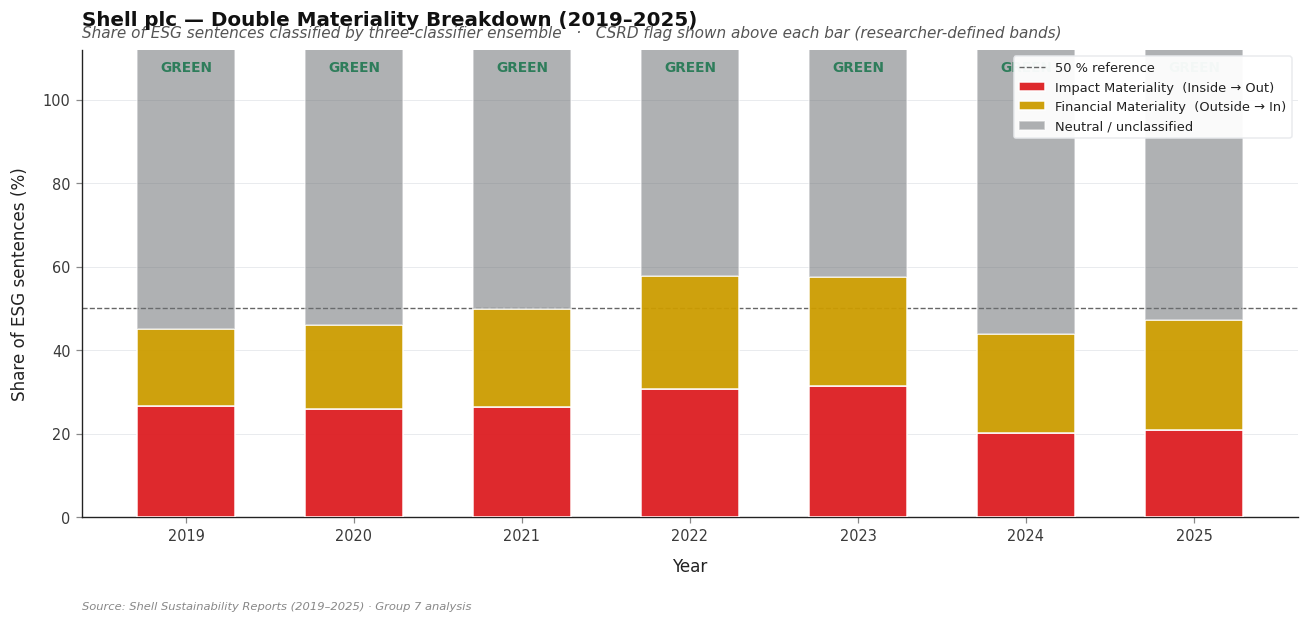

   saved: shell_L2_1_DM_Breakdown.png  |  shell_L2_1_DM_Breakdown.csv


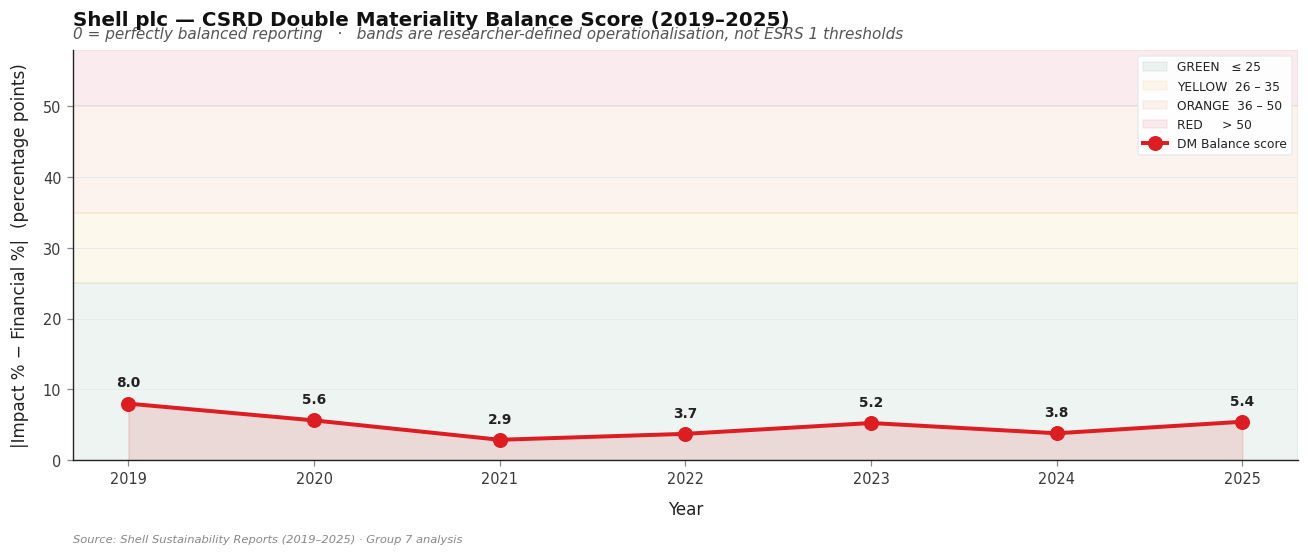

   saved: shell_L2_2_DM_Balance.png  |  shell_L2_2_DM_Balance.csv


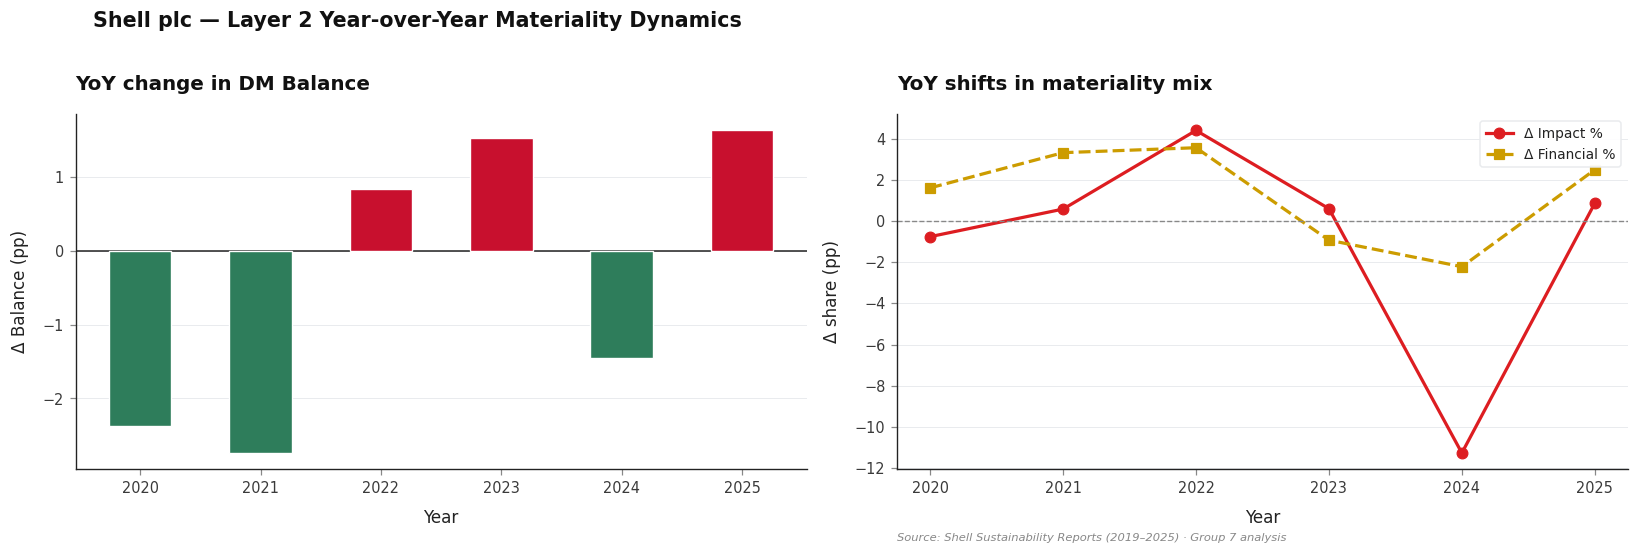

   saved: shell_L2_3_YoY.png  |  shell_L2_3_YoY.csv

Layer 2 charts complete.


In [14]:
# ╔══════════════════════════════════════════════════════════════╗
# ║  CELL 10 — LAYER 2 CHARTS  (each chart + its own CSV)        ║
# ║                                                              ║
# ║  L2-1  Double Materiality breakdown (stacked)                ║
# ║  L2-2  DM Balance trend with CSRD bands                      ║
# ║  L2-3  YoY shifts in materiality mix                         ║
# ╚══════════════════════════════════════════════════════════════╝

CSRD_COLORS = {
    "GREEN" : "#2E7D5B",
    "YELLOW": "#E1A70E",
    "ORANGE": "#E0722A",
    "RED"   : DIVERGENCE_RED,
}

if L2_DF.empty:
    print("No Layer 2 data — charts skipped.")
else:
    dm_yr = [int(y) for y in L2_DF["Year"]]
    imp_v = L2_DF["Impact_Pct"].tolist()
    fin_v = L2_DF["Financial_Pct"].tolist()
    neu_v = L2_DF["Neutral_Pct"].tolist()
    bal_v = L2_DF["DM_Balance"].tolist()
    flags = L2_DF["CSRD_Flag"].tolist()

    # ─── L2-1  Stacked breakdown ──────────────────────────────────────────
    fig, ax = plt.subplots(figsize=(12, 5.8))
    x = np.arange(len(dm_yr)); w = 0.58
    ax.bar(x, imp_v, w, label="Impact Materiality  (Inside → Out)",
           color=SHELL_RED,     alpha=0.95, edgecolor="white", lw=1.0, zorder=3)
    ax.bar(x, fin_v, w, bottom=imp_v, label="Financial Materiality  (Outside → In)",
           color=SHELL_YELLOW_DEEP, alpha=0.95, edgecolor="white", lw=1.0, zorder=3)
    bot2 = [a + b for a, b in zip(imp_v, fin_v)]
    ax.bar(x, neu_v, w, bottom=bot2, label="Neutral / unclassified",
           color=NEUTRAL_GREY, alpha=0.55, edgecolor="white", lw=1.0, zorder=3)
    ax.axhline(50, color="#666", lw=0.9, ls="--", label="50 % reference", zorder=2)
    ax.set_xticks(list(x)); ax.set_xticklabels(dm_yr)
    ax.set_ylim(0, 112)
    ax.set_title(f"{COMPANY} — Double Materiality Breakdown (2019–2025)", **TITLE_KW)
    add_subtitle(ax,
        "Share of ESG sentences classified by three-classifier ensemble   ·   "
        "CSRD flag shown above each bar (researcher-defined bands)")
    ax.set_xlabel("Year", **LABEL_KW)
    ax.set_ylabel("Share of ESG sentences (%)", **LABEL_KW)
    ax.legend(loc="upper right", fontsize=8.5)
    for xi, flag in enumerate(flags):
        ax.text(xi, 106, flag, ha="center", va="bottom",
                fontsize=9, color=CSRD_COLORS.get(flag, AXIS_DARK),
                fontweight="semibold")
    style_axes(ax); add_source_note(ax)
    plt.tight_layout()
    savefig_and_csv(fig, f"{CACHE_SLUG}_L2_1_DM_Breakdown",
                    L2_DF[["Year","Impact_Pct","Financial_Pct",
                           "Neutral_Pct","CSRD_Flag","N_ESG_Sents"]])

    # ─── L2-2  DM Balance with CSRD bands ─────────────────────────────────
    fig, ax = plt.subplots(figsize=(12, 5.2))
    y_top = max(max(bal_v) * 1.2, 58)
    bands = [
        (0,  25,  CSRD_COLORS["GREEN"],  "GREEN   ≤ 25"),
        (25, 35,  CSRD_COLORS["YELLOW"], "YELLOW  26 – 35"),
        (35, 50,  CSRD_COLORS["ORANGE"], "ORANGE  36 – 50"),
        (50, y_top, CSRD_COLORS["RED"],  "RED     > 50"),
    ]
    for lo, hi, col, lbl in bands:
        ax.axhspan(lo, hi, color=col, alpha=0.08, zorder=1, label=lbl)

    ax.plot(dm_yr, bal_v, "o-", color=SHELL_RED, lw=2.6, ms=9, zorder=4,
            label="DM Balance score")
    ax.fill_between(dm_yr, bal_v, alpha=0.12, color=SHELL_RED)
    for x, y in zip(dm_yr, bal_v):
        ax.annotate(f"{y:.1f}", (x, y), textcoords="offset points",
                    xytext=(0, 11), ha="center", fontsize=9,
                    color=AXIS_DARK, fontweight="semibold")
    ax.set_ylim(0, y_top)
    ax.set_title(f"{COMPANY} — CSRD Double Materiality Balance Score (2019–2025)", **TITLE_KW)
    add_subtitle(ax,
        "0 = perfectly balanced reporting   ·   bands are researcher-defined operationalisation, not ESRS 1 thresholds")
    ax.set_xlabel("Year", **LABEL_KW)
    ax.set_ylabel("|Impact % − Financial %|  (percentage points)", **LABEL_KW)
    ax.set_xticks(dm_yr)
    ax.legend(loc="upper right", fontsize=8)
    style_axes(ax); add_source_note(ax)
    plt.tight_layout()
    savefig_and_csv(fig, f"{CACHE_SLUG}_L2_2_DM_Balance",
                    L2_DF[["Year","DM_Balance","CSRD_Flag","N_ESG_Sents"]])

    # ─── L2-3  YoY dynamics ───────────────────────────────────────────────
    yoy = []
    for i in range(1, len(L2_DF)):
        prev = L2_DF.iloc[i-1]; curr = L2_DF.iloc[i]
        yoy.append({
            "Year"       : curr["Year"],
            "dBalance"   : round(curr["DM_Balance"]    - prev["DM_Balance"],    2),
            "dImpact"    : round(curr["Impact_Pct"]    - prev["Impact_Pct"],    2),
            "dFinancial" : round(curr["Financial_Pct"] - prev["Financial_Pct"], 2),
        })
    YOY_L2 = pd.DataFrame(yoy)

    if not YOY_L2.empty:
        fig, axes = plt.subplots(1, 2, figsize=(15, 5))
        y_yr = [int(y) for y in YOY_L2["Year"]]

        axA = axes[0]
        cols = [POSITIVE_BAR if v >= 0 else NEGATIVE_BAR for v in YOY_L2["dBalance"]]
        axA.bar(y_yr, YOY_L2["dBalance"], color=cols, width=0.52,
                edgecolor="white", lw=0.9, zorder=3)
        axA.axhline(0, color=AXIS_DARK, lw=1.0)
        axA.set_title("YoY change in DM Balance", **TITLE_KW)
        axA.set_xlabel("Year", **LABEL_KW)
        axA.set_ylabel("Δ Balance (pp)", **LABEL_KW)
        axA.set_xticks(y_yr); style_axes(axA)

        axB = axes[1]
        axB.plot(y_yr, YOY_L2["dImpact"],    "o-",  color=SHELL_RED,
                 lw=2.1, ms=7, label="Δ Impact %")
        axB.plot(y_yr, YOY_L2["dFinancial"], "s--", color=SHELL_YELLOW_DEEP,
                 lw=2.1, ms=7, label="Δ Financial %")
        axB.axhline(0, color="#888", lw=0.9, ls="--")
        axB.set_title("YoY shifts in materiality mix", **TITLE_KW)
        axB.set_xlabel("Year", **LABEL_KW)
        axB.set_ylabel("Δ share (pp)", **LABEL_KW)
        axB.set_xticks(y_yr); axB.legend(loc="best"); style_axes(axB)

        fig.suptitle(f"{COMPANY} — Layer 2 Year-over-Year Materiality Dynamics",
                     fontsize=13.5, fontweight="semibold",
                     x=0.06, y=1.02, ha="left", color="#111")
        add_source_note(axes[1])
        plt.tight_layout()
        savefig_and_csv(fig, f"{CACHE_SLUG}_L2_3_YoY", YOY_L2)

print("\nLayer 2 charts complete.")


In [15]:
# ╔══════════════════════════════════════════════════════════════╗
# ║  CELL 11 — LAYER 3 COMPUTE  ·  KEYWORD DENSITY DRIFT         ║
# ║                                                              ║
# ║  Keyword categories and Greenwashing Ratio preserved from    ║
# ║  the original proposal. NVI is added here as a bounded       ║
# ║  companion to GR (same phenomenon, scale-invariant form).    ║
# ║                                                              ║
# ║      GR  = Commit_density / max(Ops_density, ε)              ║
# ║      NVI = (Commit − Ops) / (Commit + Ops + ε)   ∈ (−1, +1)  ║
# ╚══════════════════════════════════════════════════════════════╝

KW_DICT = {
    "commitment_claims": [
        "pledge", "pledged", "pledging",
        "aim", "aiming", "aims to",
        "target", "targets", "targeted", "targeting",
        "ambition", "ambitious",
        "commit", "committed", "commitment", "commitments",
        "strive", "striving",
        "intend", "intention", "intending",
        "aspire", "aspiration", "aspirational",
        "seek to", "seeking to",
        "we will", "we plan", "we intend", "we aim",
        "we commit", "we are committed",
        "we continue to work", "we are working towards",
        "our goal", "our objective", "our vision",
        "we believe", "we expect",
        "net-zero by 2050", "net zero by 2050",
        "net zero ambition", "net zero goal",
        "net zero operations", "net zero sales",
        "paris aligned", "paris consistent",
        "science based target",
        "1.5 degree", "well below 2",
        "zero routine flaring by 2030",
        "near-zero methane",
        "carbon neutral", "carbon negative",
        "by 2025", "by 2030", "by 2035", "by 2040", "by 2050",
        "over the next", "in the coming years", "in the longer term",
        "long-term vision", "roadmap", "pathway", "milestones",
        "transition plan", "action plan", "blueprint",
        "reimagin", "aim zero", "powering progress",
        "strategy 2030", "strategy 2025",
        "50 gw", "10 gw", "capital markets update",
        "beyond petroleum",
        "accelerate", "strengthen", "embed", "enhance",
        "foster", "advance", "drive", "develop", "enable",
        "continue to", "focus on", "prioritize",
        "enabled by supportive government",
        "subject to", "contingent on", "if supported",
        "dependent on", "over time", "in due course",
        "we hope", "may", "could", "should",
        "improve people's lives", "just transition",
        "inclusive culture", "equipping employees",
        "net positive impact", "water positive",
        "biodiversity net gain",
    ],

    "operational_delivery": [
        "scope 1", "scope 2", "scope 3",
        "mtco2e", "ktco2e", "gco2e",
        "metric ton", "tonne co2", "grams co2", "gco2/mj", "gco2e/mj",
        "megawatt", "mw ", "gwh", "twh", "kwh", "mwh",
        "gigawatt", "gw ", "ej ", "mj ", "pj ", "gj ",
        "btu", "mmbtu",
        "barrel", "bpd", "mboe", "mmboe", "bcf",
        "lng", "liquefied natural gas",
        "carbon intensity", "emission intensity",
        "lifecycle carbon", "lifecycle emission",
        "absolute emission", "absolute reduction",
        "methane intensity", "methane emission",
        "installed capacity", "commissioned", "started up",
        "brought online", "operational", "came online",
        "turbine", "capacity factor",
        "refinery", "refinery availability", "plant reliability",
        "upstream plant", "major project", "capital expenditure",
        "final investment decision", "capex",
        "reduction of", "reduced by", "decreased by", "cut by",
        "% reduction", "% decrease", "% lower", "% improvement",
        "37%", "41%", "45-50%",
        "34.3 mtco2e", "0.04%",
        "flaring volume", "flare reduction",
        "zero routine flaring", "fugitive emission",
        "methane abatement", "methane management",
        "real-time monitoring", "optical gas imaging",
        "top-down measurement",
        "freshwater withdrawal", "freshwater consumption",
        "water efficiency", "brackish water",
        "mm3", "million m3",
        "iso 14001", "iso 50001",
        "ogmp 2.0", "gold status",
        "limited assurance", "externally assured",
        "deloitte", "third-party verified",
        "0.27mtco2e", "125ktco2e", "144ktco2e", "80ktco2e", "45ktco2e",
        "28ktco2e", "61ktco2e",
        "bpx energy", "tangguh", "cherry point",
        "ev charge points", "41,000", "1.5twh",
        "ultra-fast charging", "charge points",
    ],

    "risk_disclosure": [
        "transition risk", "physical risk",
        "stranded asset", "stranded assets",
        "carbon pricing", "carbon tax", "carbon cost",
        "ets", "emissions trading",
        "climate litigation", "legal risk",
        "regulatory risk", "policy risk",
        "cbam", "carbon border adjustment",
        "taxonomy regulation", "eu taxonomy",
        "sfdr", "sustainable finance",
        "impairment", "write-down", "write-off",
        "asset impairment", "goodwill impairment",
        "oil price risk", "energy price",
        "interest rate risk", "inflation risk",
        "supply chain risk", "counterparty risk",
        "credit risk", "liquidity risk",
        "geopolitical risk", "geopolitical",
        "extreme weather", "flooding", "wildfire",
        "drought", "sea level rise", "storm",
        "climate-related physical risk",
        "water stress", "water scarcity",
        "tcfd", "csrd", "double materiality",
        "materiality assessment",
        "scenario analysis", "1.5 degree scenario",
        "net zero scenario", "nia scenario",
        "transition scenario", "wbcsd scenario",
        "principal risk", "risk factor",
        "risk management", "risk assessment",
        "activist investor", "climate resolution",
        "shareholder vote", "say on climate",
        "ca100+", "follow this", "ngo pressure",
        "fatality", "fatal incident", "life-changing injury",
        "process safety event", "tier 1", "tier 2",
        "oil spill", "environmental incident",
        "regulatory enforcement", "fines",
    ],

    "governance_terms": [
        "board", "board of directors", "board committee",
        "safety and sustainability committee",
        "audit committee", "remuneration committee",
        "group operational risk committee",
        "executive committee",
        "chief executive", "ceo", "cfo", "svp",
        "governance", "oversight", "accountability",
        "disclosure", "reporting framework",
        "assurance", "limited assurance", "reasonable assurance",
        "verification", "independent verification",
        "external audit", "internal audit",
        "materiality assessment", "double materiality",
        "stakeholder engagement",
        "annual report", "form 20-f", "esg datasheet",
        "basis of reporting",
        "tcfd", "csrd", "gri", "sasb", "issb", "ifrs s2",
        "un global compact", "sdg", "ipieca",
        "tnfd", "wbcsd", "ca100+", "cdp",
        "code of conduct", "ethics", "compliance",
        "anti-bribery", "anti-corruption",
        "modern slavery", "human rights due diligence",
        "eiti", "extractive industries transparency",
        "opentalk", "speak up", "whistleblower", "non-retaliation",
        "remuneration", "bonus scorecard",
        "long-term incentive", "performance share",
        "sustainability metric", "linked to emissions",
        "executive pay", "incentive plan",
        "public policy", "policy engagement",
        "trade association", "lobbying",
        "advocacy", "political donation",
    ],

    "company_specific": COMPANY_KW_SPECIFIC,
}

EPS = 1e-6

def layer3_row(year: str, sents: List[str]) -> dict:
    text  = " ".join(sents)
    words = len(text.split())
    if words < 100:
        return {}
    row = {"Year": year, "Word_Count": words}
    for cat, kws in KW_DICT.items():
        hits = sum(text.lower().count(k.lower()) for k in kws)
        row[f"{cat}_density"] = round(hits / words * 1000, 4)

    commit = row.get("commitment_claims_density",    0.0)
    ops    = row.get("operational_delivery_density", 0.0)

    # Greenwashing Ratio (unbounded, intuitive)
    row["Greenwashing_Ratio"] = round(commit / max(ops, EPS), 4)

    # NVI  — bounded [−1, +1] companion (scale-invariant, no free params)
    row["NVI"] = round((commit - ops) / (commit + ops + EPS), 6)

    # KeyBERT semantic top-10 for transparency
    if KEYBERT_OK and KB_MODEL and len(text) > 200:
        try:
            kws_raw = KB_MODEL.extract_keywords(
                text[:15_000],
                keyphrase_ngram_range=(1, 2),
                stop_words="english",
                use_maxsum=True,
                nr_candidates=40,
                top_n=10,
            )
            row["KeyBERT_Top10"] = ", ".join(k for k, _ in kws_raw)
        except Exception:
            row["KeyBERT_Top10"] = "extraction failed"
    else:
        row["KeyBERT_Top10"] = ""
    return row

print("=" * 66)
print(f"LAYER 3 — KEYWORD DENSITY DRIFT (with NVI) — {COMPANY}")
print("=" * 66)

L3_ROWS = []
t0 = time.time()
for year in YEARS:
    sents = CORPUS.get(year, [])
    row = layer3_row(year, sents)
    if not row:
        print(f"  [SKIP] {year}: corpus too small"); continue
    L3_ROWS.append(row)
    print(
        f"  {year}  words={row['Word_Count']:>6,}  "
        f"commit={row['commitment_claims_density']:6.2f}  "
        f"ops={row['operational_delivery_density']:6.2f}  "
        f"risk={row['risk_disclosure_density']:6.2f}  "
        f"gov={row['governance_terms_density']:6.2f}  "
        f"GR={row['Greenwashing_Ratio']:.3f}  NVI={row['NVI']:+.4f}"
    )

L3_DF = pd.DataFrame(L3_ROWS)
print(f"\nLayer 3 complete in {time.time() - t0:.1f}s")
print(f"GR  observed range: [{L3_DF['Greenwashing_Ratio'].min():.3f}, {L3_DF['Greenwashing_Ratio'].max():.3f}]")
print(f"NVI observed range: [{L3_DF['NVI'].min():+.4f}, {L3_DF['NVI'].max():+.4f}]  (bounded (−1, +1))")


LAYER 3 — KEYWORD DENSITY DRIFT (with NVI) — Shell plc
  2019  words=43,661  commit= 18.00  ops=  4.51  risk=  2.22  gov=  5.34  GR=3.990  NVI=+0.5992
  2020  words=50,259  commit= 18.01  ops=  5.51  risk=  2.87  gov=  6.57  GR=3.267  NVI=+0.5313
  2021  words=33,889  commit= 22.13  ops=  8.79  risk=  4.31  gov=  9.56  GR=2.517  NVI=+0.4313
  2022  words=39,344  commit= 19.80  ops=  8.77  risk=  4.27  gov=  9.43  GR=2.258  NVI=+0.3861
  2023  words=46,058  commit= 20.37  ops=  8.77  risk=  4.28  gov=  8.32  GR=2.322  NVI=+0.3979
  2024  words=80,150  commit= 18.15  ops=  5.08  risk=  7.81  gov=  9.76  GR=3.575  NVI=+0.5628
  2025  words=86,297  commit= 18.34  ops=  5.30  risk=  8.20  gov=  9.50  GR=3.464  NVI=+0.5520

Layer 3 complete in 8.8s
GR  observed range: [2.258, 3.990]
NVI observed range: [+0.3861, +0.5992]  (bounded (−1, +1))


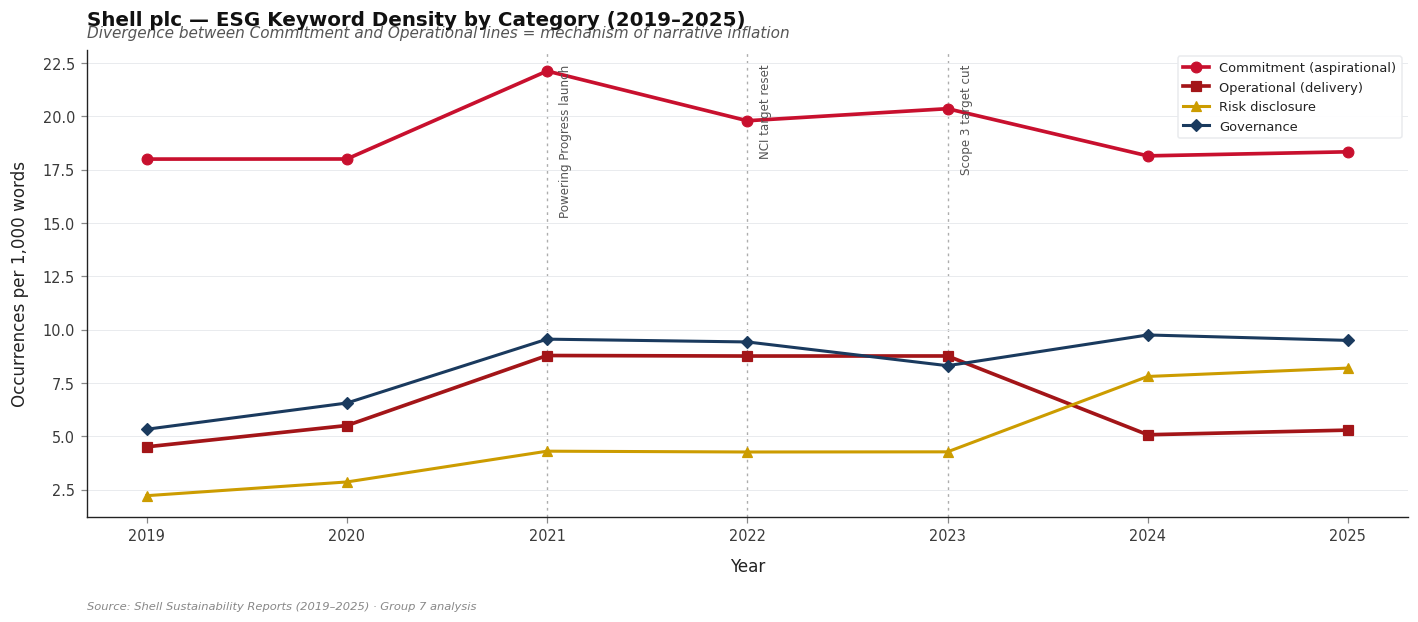

   saved: shell_L3_1_KW_Densities.png  |  shell_L3_1_KW_Densities.csv


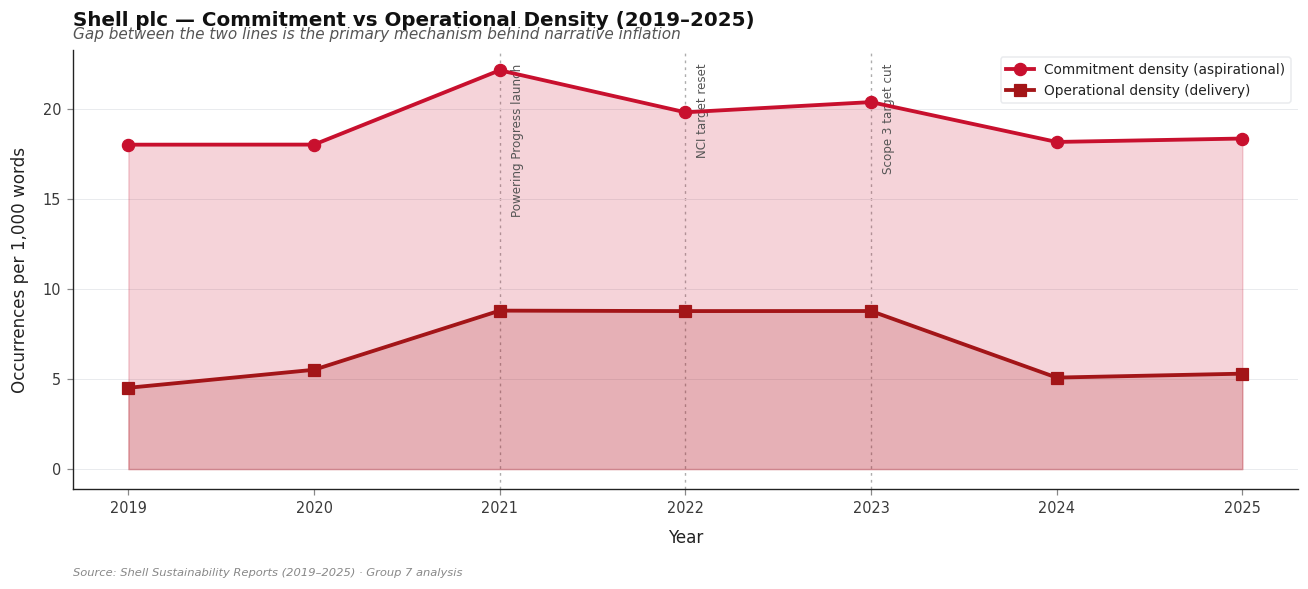

   saved: shell_L3_2_Commit_vs_Ops.png  |  shell_L3_2_Commit_vs_Ops.csv


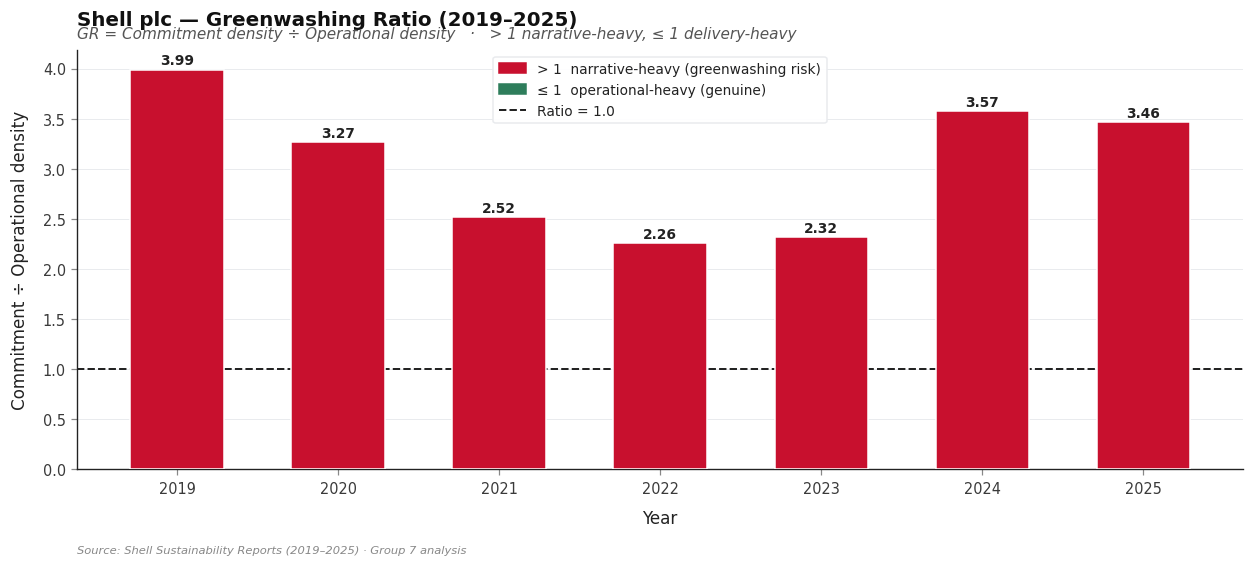

   saved: shell_L3_3_GW_Ratio.png  |  shell_L3_3_GW_Ratio.csv


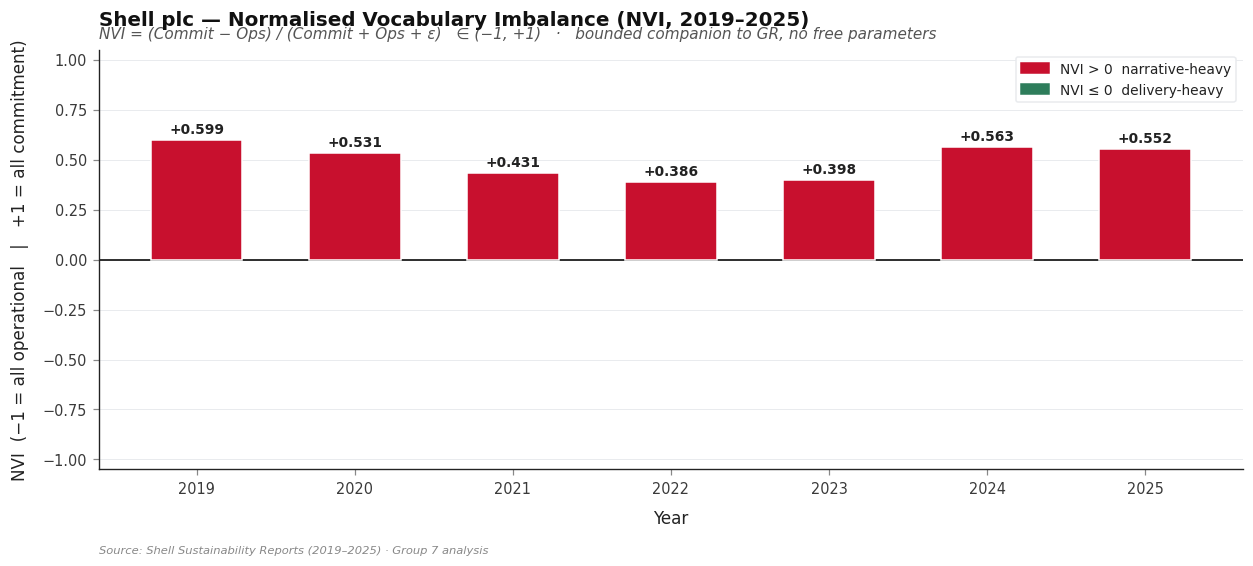

   saved: shell_L3_4_NVI.png  |  shell_L3_4_NVI.csv


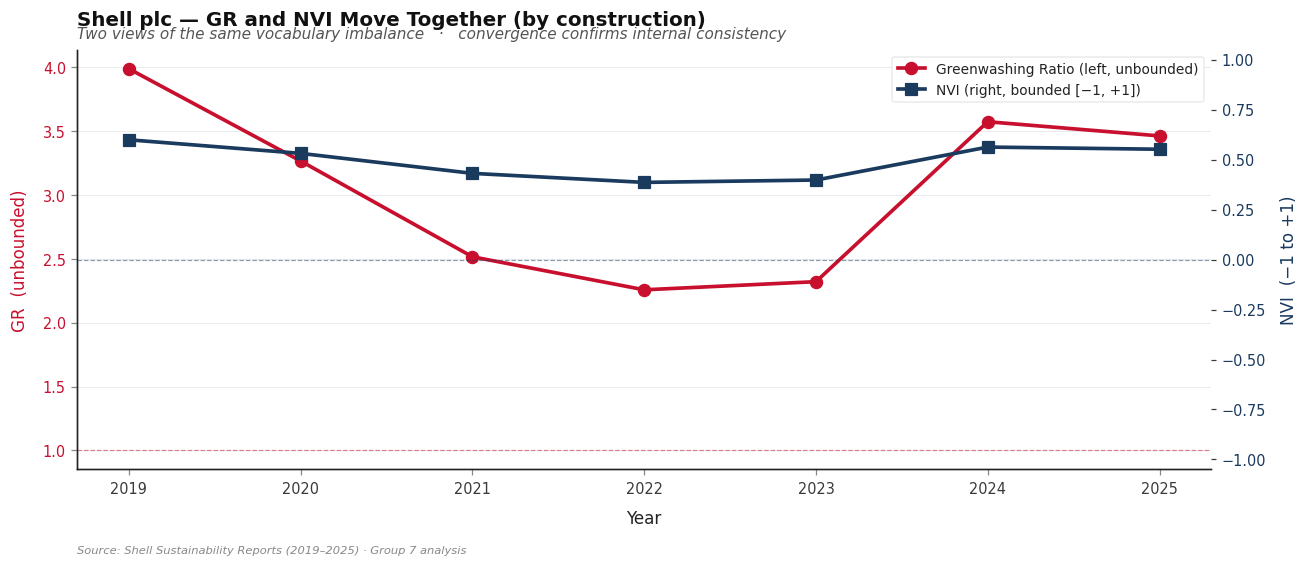

   saved: shell_L3_5_GR_NVI_Convergence.png  |  shell_L3_5_GR_NVI_Convergence.csv


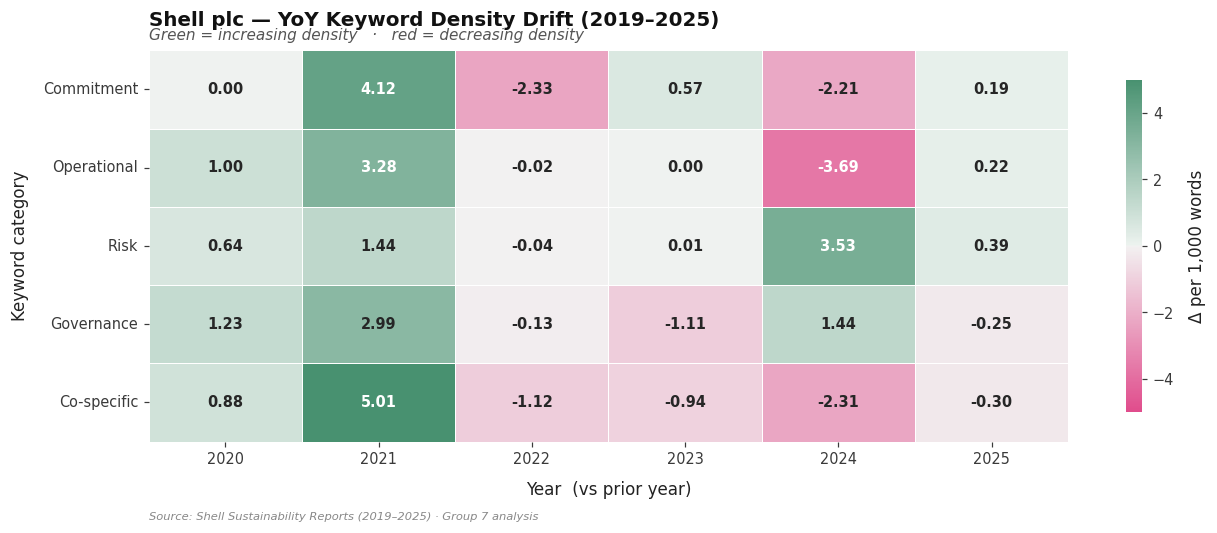

   saved: shell_L3_6_YoY_Drift.png  |  shell_L3_6_YoY_Drift.csv

Layer 3 charts complete.


In [16]:
# ╔══════════════════════════════════════════════════════════════╗
# ║  CELL 12 — LAYER 3 CHARTS  (each chart + its own CSV)        ║
# ║                                                              ║
# ║  L3-1  Keyword density by category                           ║
# ║  L3-2  Commitment vs Operational dual-area                   ║
# ║  L3-3  Greenwashing Ratio (unbounded, intuitive)             ║
# ║  L3-4  NVI (bounded [-1,+1] companion to GR)  NEW            ║
# ║  L3-5  GR & NVI convergence check                            ║
# ║  L3-6  YoY keyword drift heatmap                             ║
# ╚══════════════════════════════════════════════════════════════╝

if L3_DF.empty:
    print("No Layer 3 data — charts skipped.")
else:
    kw_yr = [int(y) for y in L3_DF["Year"]]
    com_v = L3_DF["commitment_claims_density"].tolist()
    ops_v = L3_DF["operational_delivery_density"].tolist()
    rsk_v = L3_DF["risk_disclosure_density"].tolist()
    gov_v = L3_DF["governance_terms_density"].tolist()
    gwr_v = L3_DF["Greenwashing_Ratio"].tolist()
    nvi_v = L3_DF["NVI"].tolist()

    # ─── L3-1  All categories density ─────────────────────────────────────
    fig, ax = plt.subplots(figsize=(13, 5.8))
    ax.plot(kw_yr, com_v, "o-",  color=DIVERGENCE_RED,         lw=2.4, ms=7, label="Commitment (aspirational)")
    ax.plot(kw_yr, ops_v, "s-",  color=SHELL_RED_DEEP,  lw=2.4, ms=7, label="Operational (delivery)")
    ax.plot(kw_yr, rsk_v, "^-",  color=SHELL_YELLOW_DEEP,   lw=2.0, ms=6, label="Risk disclosure")
    ax.plot(kw_yr, gov_v, "D-",  color=SHELL_NAVY,        lw=2.0, ms=6, label="Governance")
    ax.set_title(f"{COMPANY} — ESG Keyword Density by Category (2019–2025)", **TITLE_KW)
    add_subtitle(ax,
        "Divergence between Commitment and Operational lines = mechanism of narrative inflation")
    ax.set_xlabel("Year", **LABEL_KW)
    ax.set_ylabel("Occurrences per 1,000 words", **LABEL_KW)
    ax.set_xticks(kw_yr); ax.legend(loc="best", fontsize=8.5)
    mark_events(ax, EVENT_MARKERS)
    style_axes(ax); add_source_note(ax)
    plt.tight_layout()
    savefig_and_csv(fig, f"{CACHE_SLUG}_L3_1_KW_Densities",
                    L3_DF[["Year","commitment_claims_density",
                           "operational_delivery_density",
                           "risk_disclosure_density",
                           "governance_terms_density",
                           "company_specific_density","Word_Count"]])

    # ─── L3-2  Commitment vs Operational dual-fill ────────────────────────
    fig, ax = plt.subplots(figsize=(12, 5.5))
    ax.fill_between(kw_yr, com_v, alpha=0.18, color=DIVERGENCE_RED,        zorder=2)
    ax.fill_between(kw_yr, ops_v, alpha=0.18, color=SHELL_RED_DEEP, zorder=2)
    ax.plot(kw_yr, com_v, "o-", color=DIVERGENCE_RED,        lw=2.5, ms=8,
            label="Commitment density (aspirational)", zorder=4)
    ax.plot(kw_yr, ops_v, "s-", color=SHELL_RED_DEEP, lw=2.5, ms=8,
            label="Operational density (delivery)",  zorder=4)
    ax.set_title(f"{COMPANY} — Commitment vs Operational Density (2019–2025)", **TITLE_KW)
    add_subtitle(ax,
        "Gap between the two lines is the primary mechanism behind narrative inflation")
    ax.set_xlabel("Year", **LABEL_KW)
    ax.set_ylabel("Occurrences per 1,000 words", **LABEL_KW)
    ax.set_xticks(kw_yr); ax.legend(loc="best")
    mark_events(ax, EVENT_MARKERS)
    style_axes(ax); add_source_note(ax)
    plt.tight_layout()
    savefig_and_csv(fig, f"{CACHE_SLUG}_L3_2_Commit_vs_Ops",
                    L3_DF[["Year","commitment_claims_density",
                           "operational_delivery_density"]])

    # ─── L3-3  Greenwashing Ratio ─────────────────────────────────────────
    fig, ax = plt.subplots(figsize=(11.5, 5.3))
    bar_c = [POSITIVE_BAR if r > 1.0 else NEGATIVE_BAR for r in gwr_v]
    bars  = ax.bar(kw_yr, gwr_v, color=bar_c, width=0.58,
                   edgecolor="white", lw=1.0, zorder=3)
    ax.axhline(1.0, color=AXIS_DARK, lw=1.3, ls="--", label="Ratio = 1.0 (balanced)")
    for bar, val in zip(bars, gwr_v):
        ax.text(bar.get_x() + bar.get_width()/2, val + 0.02,
                f"{val:.2f}", ha="center", va="bottom",
                fontsize=9, fontweight="semibold", color=AXIS_DARK)
    ax.set_title(f"{COMPANY} — Greenwashing Ratio (2019–2025)", **TITLE_KW)
    add_subtitle(ax,
        "GR = Commitment density ÷ Operational density   ·   > 1 narrative-heavy, ≤ 1 delivery-heavy")
    ax.set_xlabel("Year", **LABEL_KW)
    ax.set_ylabel("Commitment ÷ Operational density", **LABEL_KW)
    ax.set_xticks(kw_yr)
    pos_p = mpatches.Patch(color=POSITIVE_BAR, label="> 1  narrative-heavy (greenwashing risk)")
    neg_p = mpatches.Patch(color=NEGATIVE_BAR, label="≤ 1  operational-heavy (genuine)")
    ax.legend(handles=[pos_p, neg_p,
                       Line2D([0],[0], color=AXIS_DARK, ls="--", lw=1.3, label="Ratio = 1.0")],
              loc="best")
    style_axes(ax); add_source_note(ax)
    plt.tight_layout()
    savefig_and_csv(fig, f"{CACHE_SLUG}_L3_3_GW_Ratio",
                    L3_DF[["Year","Greenwashing_Ratio",
                           "commitment_claims_density",
                           "operational_delivery_density"]])

    # ─── L3-4  NVI (bounded) ─────────────────────────────────────────────
    fig, ax = plt.subplots(figsize=(11.5, 5.3))
    bar_c = [POSITIVE_BAR if v > 0 else NEGATIVE_BAR for v in nvi_v]
    bars = ax.bar(kw_yr, nvi_v, color=bar_c, width=0.58,
                  edgecolor="white", lw=1.0, zorder=3)
    ax.axhline(0, color=AXIS_DARK, lw=1.2)
    for bar, val in zip(bars, nvi_v):
        va = "bottom" if val >= 0 else "top"
        off = 0.02 if val >= 0 else -0.02
        ax.text(bar.get_x() + bar.get_width()/2, val + off,
                f"{val:+.3f}", ha="center", va=va,
                fontsize=9, fontweight="semibold", color=AXIS_DARK)
    ax.set_ylim(-1.05, 1.05)
    ax.set_title(f"{COMPANY} — Normalised Vocabulary Imbalance (NVI, 2019–2025)", **TITLE_KW)
    add_subtitle(ax,
        "NVI = (Commit − Ops) / (Commit + Ops + ε)   ∈ (−1, +1)   ·   "
        "bounded companion to GR, no free parameters")
    ax.set_xlabel("Year", **LABEL_KW)
    ax.set_ylabel("NVI  (−1 = all operational   |   +1 = all commitment)", **LABEL_KW)
    ax.set_xticks(kw_yr)
    ax.legend(handles=[
        mpatches.Patch(color=POSITIVE_BAR, label="NVI > 0  narrative-heavy"),
        mpatches.Patch(color=NEGATIVE_BAR, label="NVI ≤ 0  delivery-heavy"),
    ], loc="best")
    style_axes(ax); add_source_note(ax)
    plt.tight_layout()
    savefig_and_csv(fig, f"{CACHE_SLUG}_L3_4_NVI",
                    L3_DF[["Year","NVI","Greenwashing_Ratio",
                           "commitment_claims_density",
                           "operational_delivery_density"]])

    # ─── L3-5  GR & NVI convergence panel ─────────────────────────────────
    fig, ax = plt.subplots(figsize=(12, 5.3))
    ax.plot(kw_yr, gwr_v, "o-", color=DIVERGENCE_RED, lw=2.4, ms=8,
            label="Greenwashing Ratio (left, unbounded)", zorder=4)
    label_kw_for_ylabel = {k: v for k, v in LABEL_KW.items() if k != 'color'}
    ax.set_ylabel("GR  (unbounded)", **label_kw_for_ylabel, color=DIVERGENCE_RED)
    ax.tick_params(axis="y", labelcolor=DIVERGENCE_RED)
    ax.axhline(1.0, color=DIVERGENCE_RED, lw=0.8, ls="--", alpha=0.5)

    ax2 = ax.twinx()
    ax2.plot(kw_yr, nvi_v, "s-", color=SHELL_NAVY, lw=2.4, ms=8,
             label="NVI (right, bounded [−1, +1])", zorder=5)
    label_kw_for_ylabel2 = {k: v for k, v in LABEL_KW.items() if k != 'color'}
    ax2.set_ylabel("NVI  (−1 to +1)", **label_kw_for_ylabel2, color=SHELL_NAVY)
    ax2.tick_params(axis="y", labelcolor=SHELL_NAVY)
    ax2.set_ylim(-1.05, 1.05)
    ax2.axhline(0, color=SHELL_NAVY, lw=0.8, ls="--", alpha=0.5)

    ax.set_title(f"{COMPANY} — GR and NVI Move Together (by construction)", **TITLE_KW)
    add_subtitle(ax,
        "Two views of the same vocabulary imbalance   ·   convergence confirms internal consistency")
    ax.set_xlabel("Year", **LABEL_KW); ax.set_xticks(kw_yr)
    lines1, lbls1 = ax.get_legend_handles_labels()
    lines2, lbls2 = ax2.get_legend_handles_labels()
    ax.legend(lines1 + lines2, lbls1 + lbls2, loc="best", fontsize=9)
    style_axes(ax); ax2.spines["top"].set_visible(False)
    add_source_note(ax)
    plt.tight_layout()
    savefig_and_csv(fig, f"{CACHE_SLUG}_L3_5_GR_NVI_Convergence",
                    L3_DF[["Year","Greenwashing_Ratio","NVI"]])

    # ─── L3-6  YoY drift heatmap ──────────────────────────────────────────
    drift_cols = [
        "commitment_claims_density", "operational_delivery_density",
        "risk_disclosure_density",   "governance_terms_density",
        "company_specific_density",
    ]
    drift_rows = []
    for i in range(1, len(L3_DF)):
        prev = L3_DF.iloc[i-1]; curr = L3_DF.iloc[i]
        row_d = {"Year": curr["Year"]}
        for col in drift_cols:
            row_d[f"d_{col}"] = round(curr[col] - prev[col], 4)
        drift_rows.append(row_d)
    DRIFT_DF = pd.DataFrame(drift_rows)

    if not DRIFT_DF.empty:
        heat_cols = [f"d_{c}" for c in drift_cols]
        heat_labels = ["Commitment", "Operational", "Risk", "Governance", "Co-specific"]
        heat_data = DRIFT_DF[heat_cols].values.T

        fig, ax = plt.subplots(figsize=(12, 5))
        vmax = max(abs(heat_data.min()), abs(heat_data.max()), 0.5)
        sns.heatmap(
            heat_data, ax=ax,
            xticklabels=[str(y) for y in DRIFT_DF["Year"]],
            yticklabels=heat_labels,
            cmap=DIVERGING_CMAP, center=0, vmin=-vmax, vmax=vmax,
            annot=True, fmt=".2f", annot_kws={"size": 9.5, "weight": "semibold"},
            linewidths=0.6, linecolor="white",
            cbar_kws={"label": "Δ per 1,000 words", "shrink": 0.85},
            square=False,
        )
        ax.set_title(f"{COMPANY} — YoY Keyword Density Drift (2019–2025)", **TITLE_KW)
        add_subtitle(ax, "Green = increasing density   ·   red = decreasing density")
        ax.set_xlabel("Year  (vs prior year)", **LABEL_KW)
        ax.set_ylabel("Keyword category", **LABEL_KW)
        plt.xticks(rotation=0); plt.yticks(rotation=0)
        add_source_note(ax)
        plt.tight_layout()
        savefig_and_csv(fig, f"{CACHE_SLUG}_L3_6_YoY_Drift", DRIFT_DF)

print("\nLayer 3 charts complete.")


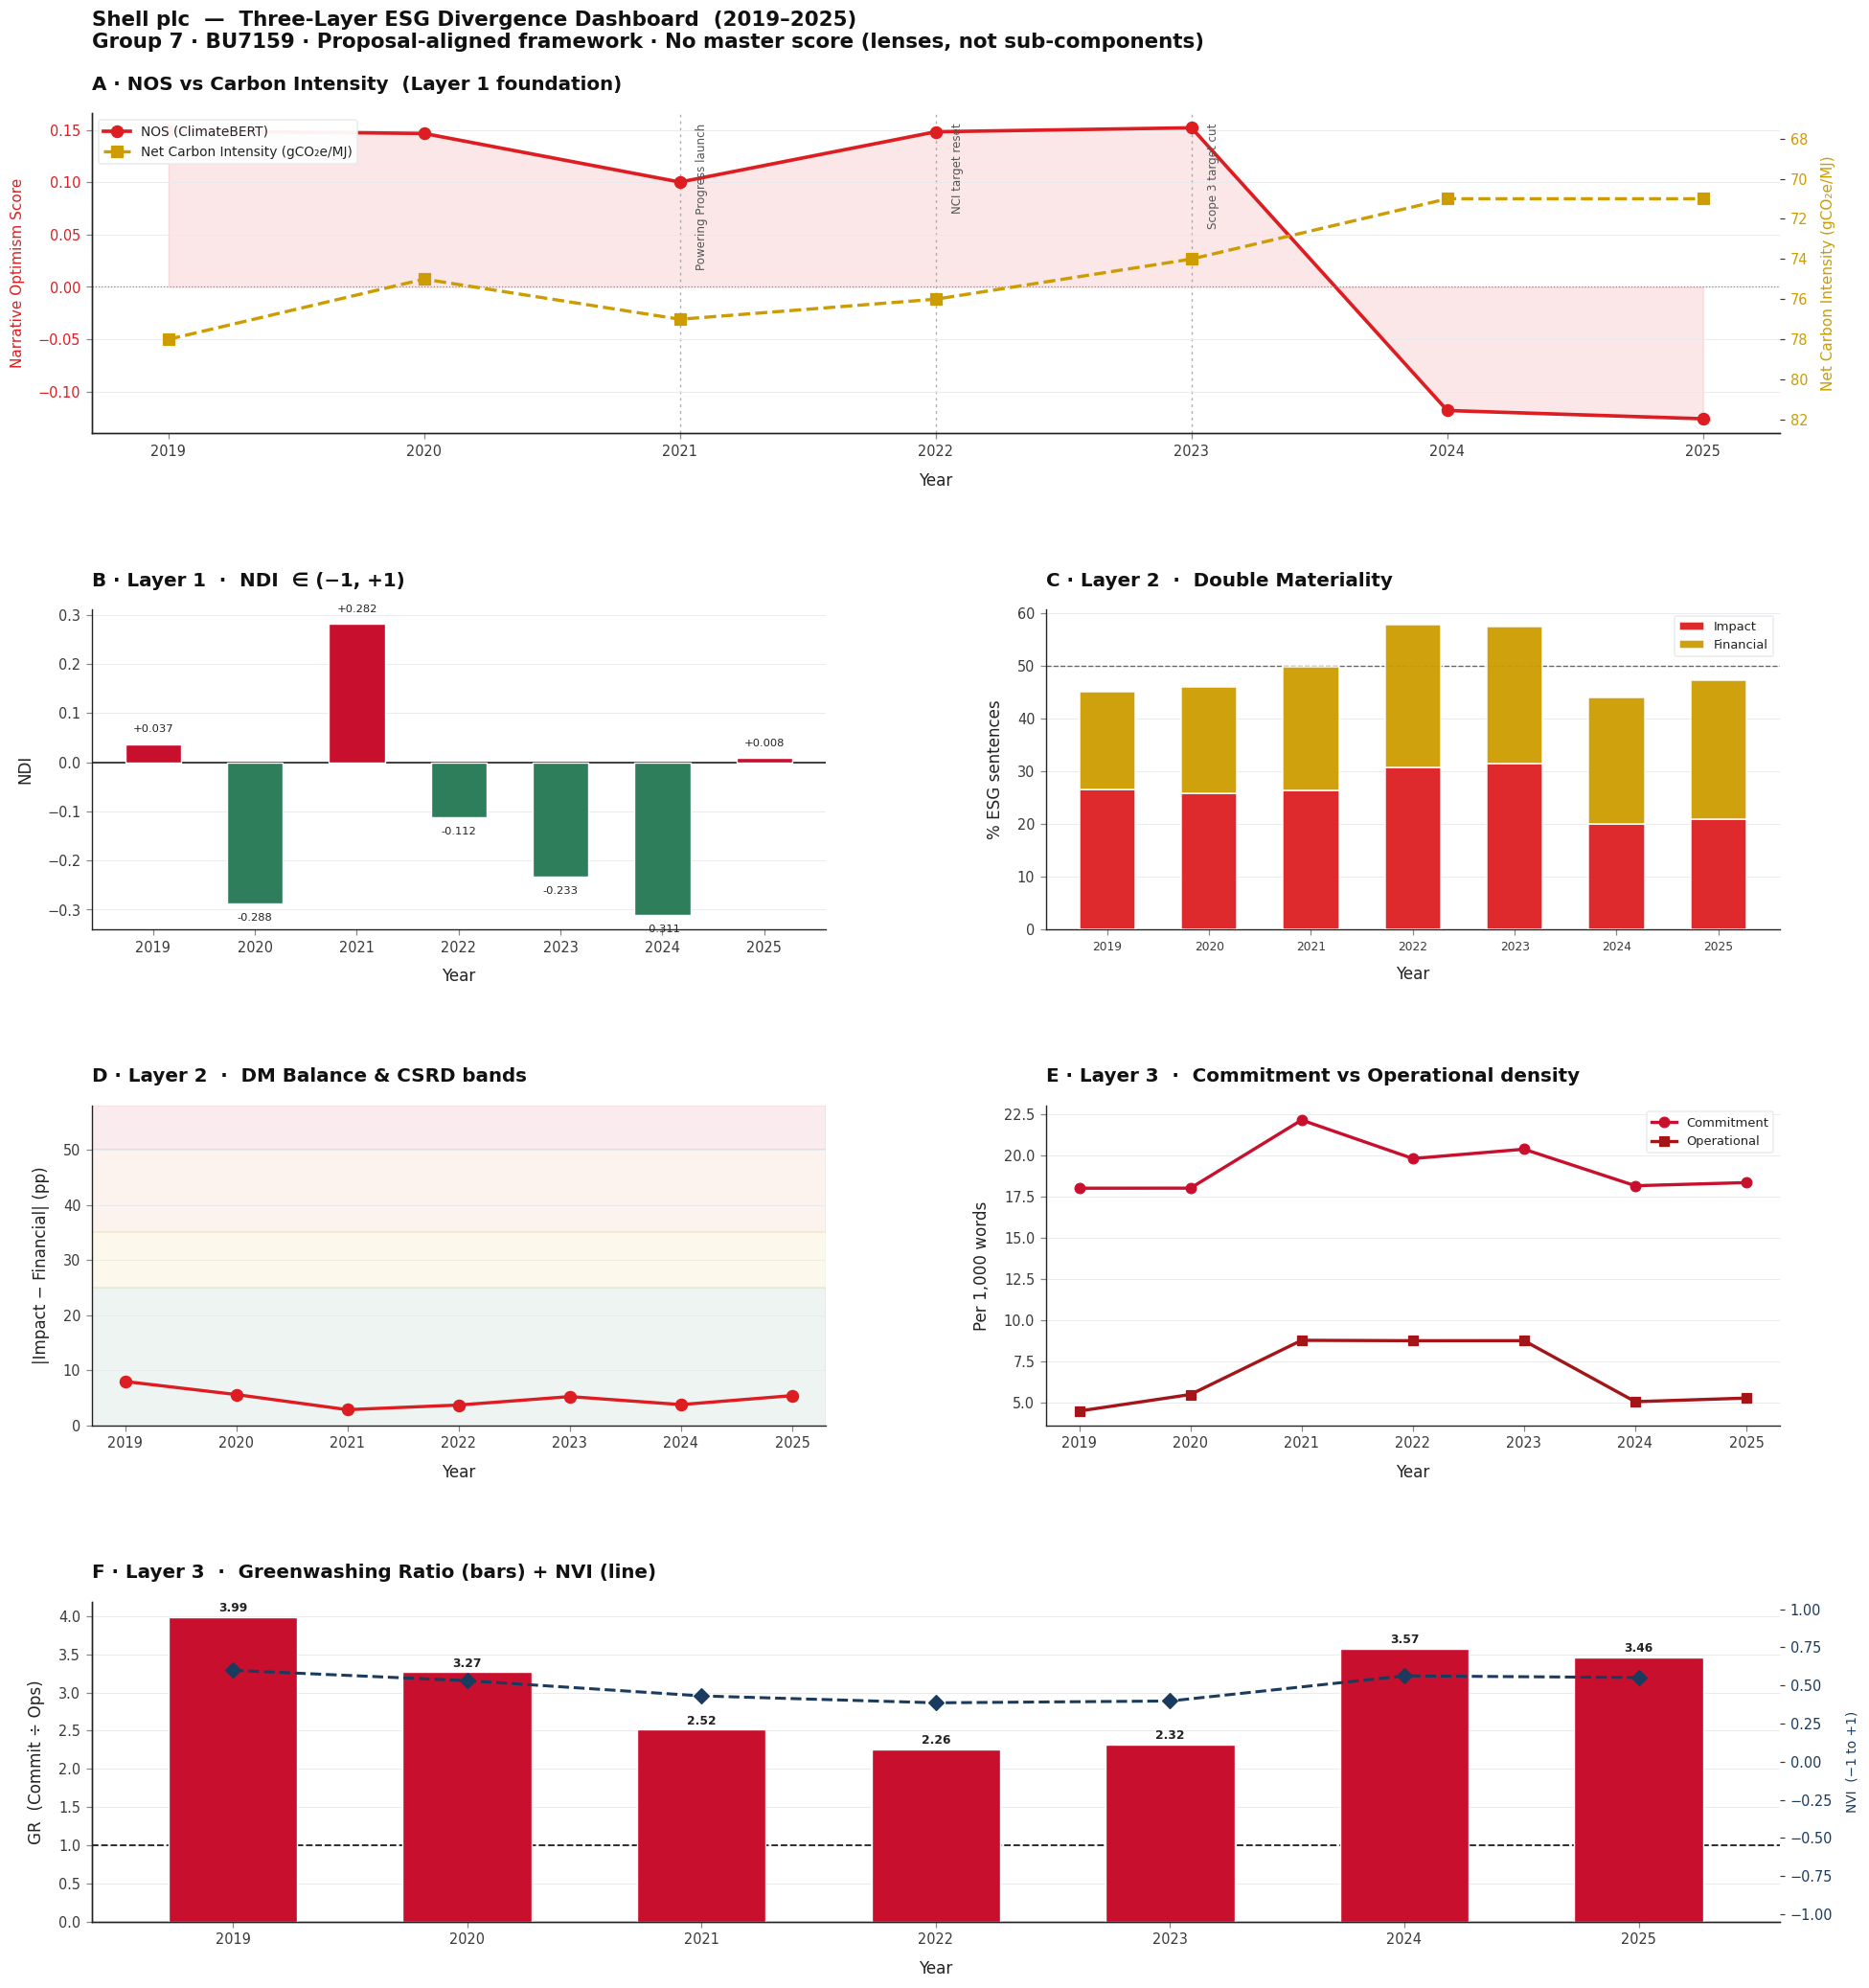

   saved: shell_DASHBOARD.png


In [17]:
# ╔══════════════════════════════════════════════════════════════╗
# ║  CELL 13 — THREE-LAYER CO-MOVEMENT DASHBOARD                 ║
# ║                                                              ║
# ║  Visual synthesis ONLY — the three layers remain independent ║
# ║  analytical outputs. No master score is computed. This panel ║
# ║  simply places each layer's headline indicator side-by-side  ║
# ║  so their co-movement can be inspected visually.             ║
# ╚══════════════════════════════════════════════════════════════╝

fig = plt.figure(figsize=(18, 19.5))
gs  = gridspec.GridSpec(
    4, 2, figure=fig,
    hspace=0.55, wspace=0.30,
    left=0.07, right=0.96, top=0.93, bottom=0.05,
)

# ── Panel A — NOS vs Carbon Intensity (dual-axis, full width) ────────────────
axA = fig.add_subplot(gs[0, :])
if not L1_DF.empty:
    yr = [int(y) for y in L1_DF["Year"]]
    axA.plot(yr, L1_DF["NOS_Overall"], "o-", color=SHELL_RED, lw=2.4, ms=8,
             label="NOS (ClimateBERT)")
    axA.fill_between(yr, L1_DF["NOS_Overall"], alpha=0.10, color=SHELL_RED)
    axA.axhline(0, color="#888", lw=0.8, ls=":")
    axA.set_ylabel("Narrative Optimism Score", color=SHELL_RED, fontsize=10)
    axA.tick_params(axis="y", labelcolor=SHELL_RED)
    axAr = axA.twinx()
    emi  = L1_DF["Emissions"].tolist()
    axAr.plot(yr, emi, "s--", color=SHELL_YELLOW_DEEP, lw=2.2, ms=8, label=EMI_LABEL)
    axAr.set_ylabel(EMI_LABEL, color=SHELL_YELLOW_DEEP, fontsize=10)
    axAr.tick_params(axis="y", labelcolor=SHELL_YELLOW_DEEP)
    axAr.invert_yaxis()
    axAr.set_ylim(max(emi) * 1.06, min(emi) * 0.94)  # still inverted
    lines1, lbls1 = axA.get_legend_handles_labels()
    lines2, lbls2 = axAr.get_legend_handles_labels()
    axA.legend(lines1 + lines2, lbls1 + lbls2, loc="upper left", fontsize=9)
    mark_events(axA, EVENT_MARKERS)
axA.set_title("A · NOS vs Carbon Intensity  (Layer 1 foundation)", **TITLE_KW)
axA.set_xlabel("Year", **LABEL_KW); axA.set_xticks([int(y) for y in YEARS])
style_axes(axA); axAr.spines["top"].set_visible(False)

# ── Panel B — NDI bar chart ──────────────────────────────────────────────────
axB = fig.add_subplot(gs[1, 0])
if not L1_DF.empty:
    yr2 = [int(y) for y in L1_DF["Year"]]; ndi = L1_DF["NDI"].tolist()
    bc  = [POSITIVE_BAR if g > 0 else NEGATIVE_BAR for g in ndi]
    axB.bar(yr2, ndi, color=bc, width=0.55, edgecolor="white", lw=0.9, zorder=3)
    axB.axhline(0, color=AXIS_DARK, lw=1.1)
    for x, y in zip(yr2, ndi):
        axB.text(x, y + (0.02 if y >= 0 else -0.02),
                 f"{y:+.3f}", ha="center",
                 va=("bottom" if y >= 0 else "top"),
                 fontsize=7.5, color=AXIS_DARK)
axB.set_title("B · Layer 1  ·  NDI  ∈ (−1, +1)", **TITLE_KW)
axB.set_xlabel("Year", **LABEL_KW); axB.set_ylabel("NDI", **LABEL_KW)
style_axes(axB)

# ── Panel C — DM stacked bar ─────────────────────────────────────────────────
axC = fig.add_subplot(gs[1, 1])
if not L2_DF.empty:
    dm = [int(y) for y in L2_DF["Year"]]
    axC.bar(range(len(dm)), L2_DF["Impact_Pct"], 0.55, color=SHELL_RED,
            alpha=0.95, label="Impact", edgecolor="white", lw=1.0, zorder=3)
    axC.bar(range(len(dm)), L2_DF["Financial_Pct"], 0.55,
            bottom=L2_DF["Impact_Pct"], color=SHELL_YELLOW_DEEP, alpha=0.95,
            label="Financial", edgecolor="white", lw=1.0, zorder=3)
    axC.set_xticks(range(len(dm))); axC.set_xticklabels(dm, fontsize=8)
    axC.axhline(50, color="#666", ls="--", lw=0.9)
axC.set_title("C · Layer 2  ·  Double Materiality", **TITLE_KW)
axC.set_xlabel("Year", **LABEL_KW); axC.set_ylabel("% ESG sentences", **LABEL_KW)
axC.legend(fontsize=8.5, loc="upper right"); style_axes(axC)

# ── Panel D — DM Balance with bands ──────────────────────────────────────────
axD = fig.add_subplot(gs[2, 0])
if not L2_DF.empty:
    dm = [int(y) for y in L2_DF["Year"]]
    y_top = max(L2_DF["DM_Balance"].max() * 1.2, 58)
    axD.axhspan(0, 25,    color=CSRD_COLORS["GREEN"],  alpha=0.08)
    axD.axhspan(25, 35,   color=CSRD_COLORS["YELLOW"], alpha=0.08)
    axD.axhspan(35, 50,   color=CSRD_COLORS["ORANGE"], alpha=0.08)
    axD.axhspan(50, y_top,color=CSRD_COLORS["RED"],    alpha=0.08)
    axD.plot(dm, L2_DF["DM_Balance"], "o-",
             color=SHELL_RED, lw=2.2, ms=8, zorder=4)
    axD.set_xticks(dm); axD.set_ylim(0, y_top)
axD.set_title("D · Layer 2  ·  DM Balance & CSRD bands", **TITLE_KW)
axD.set_xlabel("Year", **LABEL_KW)
axD.set_ylabel("|Impact − Financial| (pp)", **LABEL_KW)
style_axes(axD)

# ── Panel E — Keyword densities (Commit vs Ops) ──────────────────────────────
axE = fig.add_subplot(gs[2, 1])
if not L3_DF.empty:
    kw = [int(y) for y in L3_DF["Year"]]
    axE.plot(kw, L3_DF["commitment_claims_density"],    "o-",
             color=DIVERGENCE_RED, lw=2.2, ms=7, label="Commitment")
    axE.plot(kw, L3_DF["operational_delivery_density"], "s-",
             color=SHELL_RED_DEEP, lw=2.2, ms=7, label="Operational")
    axE.set_xticks(kw); axE.legend(fontsize=8.5)
axE.set_title("E · Layer 3  ·  Commitment vs Operational density", **TITLE_KW)
axE.set_xlabel("Year", **LABEL_KW); axE.set_ylabel("Per 1,000 words", **LABEL_KW)
style_axes(axE)

# ── Panel F — GR + NVI convergence (full width) ──────────────────────────────
axF = fig.add_subplot(gs[3, :])
if not L3_DF.empty:
    kw = [int(y) for y in L3_DF["Year"]]
    gr = L3_DF["Greenwashing_Ratio"].tolist()
    bc = [POSITIVE_BAR if r > 1.0 else NEGATIVE_BAR for r in gr]
    axF.bar(kw, gr, color=bc, width=0.55, edgecolor="white", lw=0.9, zorder=3)
    axF.axhline(1.0, color=AXIS_DARK, lw=1.2, ls="--", label="GR = 1.0")
    for xv, yv in zip(kw, gr):
        axF.text(xv, yv + 0.03, f"{yv:.2f}", ha="center",
                 va="bottom", fontsize=8, color=AXIS_DARK, fontweight="semibold")
    axFr = axF.twinx()
    axFr.plot(kw, L3_DF["NVI"], "D--", color=SHELL_NAVY, lw=2.0, ms=7,
              label="NVI (right axis)", zorder=5)
    axFr.set_ylabel("NVI  (−1 to +1)", color=SHELL_NAVY, fontsize=9)
    axFr.tick_params(axis="y", labelcolor=SHELL_NAVY); axFr.set_ylim(-1.05, 1.05)
    axFr.spines["top"].set_visible(False)
    axF.set_xticks(kw)
axF.set_title("F · Layer 3  ·  Greenwashing Ratio (bars) + NVI (line)", **TITLE_KW)
axF.set_xlabel("Year", **LABEL_KW); axF.set_ylabel("GR  (Commit ÷ Ops)", **LABEL_KW)
style_axes(axF)

fig.suptitle(
    f"{COMPANY}  —  Three-Layer ESG Divergence Dashboard  (2019–2025)\n"
    "Group 7 · BU7159 · Proposal-aligned framework · No master score (lenses, not sub-components)",
    fontsize=14, fontweight="semibold", x=0.07, y=0.98, ha="left", color="#111",
)
dashboard_path = OUTPUT_DIR / f"{CACHE_SLUG}_DASHBOARD.png"
fig.savefig(dashboard_path, dpi=300, bbox_inches="tight", facecolor="white")
plt.show()
print(f"   saved: {dashboard_path.name}")


In [18]:
# ╔══════════════════════════════════════════════════════════════╗
# ║  CELL 14 — FINAL MERGED RESULTS + CROSS-LAYER VALIDATION     ║
# ╚══════════════════════════════════════════════════════════════╝

if not L1_DF.empty and not L2_DF.empty and not L3_DF.empty:
    merged = L1_DF.merge(
        L2_DF[["Year","Impact_Pct","Financial_Pct","DM_Balance","CSRD_Flag"]],
        on="Year", how="left",
    )
    merged = merged.merge(
        L3_DF[["Year","commitment_claims_density","operational_delivery_density",
               "Greenwashing_Ratio","NVI","KeyBERT_Top10"]],
        on="Year", how="left",
    )
    out_csv = OUTPUT_DIR / f"{CACHE_SLUG}_ESG_Full_Results.csv"
    merged.to_csv(out_csv, index=False)
    print(f"Full merged results → {out_csv.name}\n")

    print("=" * 96)
    print(f"FINAL REPORT TABLE  —  {COMPANY}")
    print("=" * 96)
    display_cols = [
        "Year","NOS_Overall","NOS_Aspirational","NOS_Operational","ARG",
        "DeltaEmit_YoY_%","EPD","NDI",
        "DM_Balance","CSRD_Flag",
        "Greenwashing_Ratio","NVI",
    ]
    print(merged[display_cols].to_string(index=False))

    # ── Cross-layer co-movement diagnostics (indicative, N=7) ──────────────
    print("\n── Cross-layer co-movement diagnostics ─────────────────────────────")
    print("  (N is small; Pearson/Spearman are indicative only — time-series)")
    if len(merged) >= 4:
        # NDI vs GR
        r, p = pearsonr(merged["NDI"].tolist(), merged["Greenwashing_Ratio"].tolist())
        s, _ = spearmanr(merged["NDI"].tolist(), merged["Greenwashing_Ratio"].tolist())
        print(f"  NDI ↔ GR       Pearson r = {r:+.3f}  (p={p:.2f})   Spearman ρ = {s:+.3f}")
        # NDI vs NVI
        r, p = pearsonr(merged["NDI"].tolist(), merged["NVI"].tolist())
        s, _ = spearmanr(merged["NDI"].tolist(), merged["NVI"].tolist())
        print(f"  NDI ↔ NVI      Pearson r = {r:+.3f}  (p={p:.2f})   Spearman ρ = {s:+.3f}")
        # NDI vs DM_Balance
        r, p = pearsonr(merged["NDI"].tolist(), merged["DM_Balance"].tolist())
        s, _ = spearmanr(merged["NDI"].tolist(), merged["DM_Balance"].tolist())
        print(f"  NDI ↔ DM_Bal   Pearson r = {r:+.3f}  (p={p:.2f})   Spearman ρ = {s:+.3f}")
        # GR vs NVI (should be monotonic by construction)
        r, p = pearsonr(merged["Greenwashing_Ratio"].tolist(), merged["NVI"].tolist())
        s, _ = spearmanr(merged["Greenwashing_Ratio"].tolist(), merged["NVI"].tolist())
        print(f"  GR  ↔ NVI      Pearson r = {r:+.3f}  (p={p:.2f})   Spearman ρ = {s:+.3f}  "
              "(monotonic by construction)")
        # ARG vs NDI
        r, p = pearsonr(merged["ARG"].tolist(), merged["NDI"].tolist())
        s, _ = spearmanr(merged["ARG"].tolist(), merged["NDI"].tolist())
        print(f"  ARG ↔ NDI      Pearson r = {r:+.3f}  (p={p:.2f})   Spearman ρ = {s:+.3f}")

    # Save diagnostics as its own CSV ------------------------------------------
    diag_rows = []
    if len(merged) >= 4:
        pairs = [
            ("NDI", "Greenwashing_Ratio"),
            ("NDI", "NVI"),
            ("NDI", "DM_Balance"),
            ("Greenwashing_Ratio", "NVI"),
            ("ARG", "NDI"),
        ]
        for a, b in pairs:
            r, p = pearsonr(merged[a].tolist(), merged[b].tolist())
            s, _ = spearmanr(merged[a].tolist(), merged[b].tolist())
            diag_rows.append({
                "pair": f"{a} vs {b}",
                "pearson_r": round(r, 4),
                "pearson_p": round(p, 4),
                "spearman_rho": round(s, 4),
                "N": len(merged),
            })
    pd.DataFrame(diag_rows).to_csv(
        OUTPUT_DIR / f"{CACHE_SLUG}_cross_layer_diagnostics.csv", index=False
    )

    # ── Narrative summary ───────────────────────────────────────────────────
    summary_lines = []
    summary_lines.append(f"# {COMPANY} — ESG Narrative Divergence Analysis (2019–2025)\n")
    summary_lines.append("Generated by Group 7 · BU7159 · FINAL framework\n\n")
    summary_lines.append("## Layer 1 — Narrative Divergence Index (NDI)\n\n")
    summary_lines.append(f"Observed NDI range: [{L1_DF['NDI'].min():+.4f}, {L1_DF['NDI'].max():+.4f}]  "
                         f"(theoretical (−1, +1))\n")
    summary_lines.append(f"Observed ARG range: [{L1_DF['ARG'].min():+.4f}, {L1_DF['ARG'].max():+.4f}]\n")
    summary_lines.append(f"Observed EPD range: [{L1_DF['EPD'].min():+.4f}, {L1_DF['EPD'].max():+.4f}]\n\n")
    for _, row in L1_DF.iterrows():
        summary_lines.append(
            f"- **{row['Year']}** · NDI = {row['NDI']:+.4f}  "
            f"(ARG {row['ARG']:+.4f}  +  EPD {row['EPD']:+.4f}) / 2\n"
        )

    summary_lines.append("\n## Layer 2 — Double Materiality Balance\n\n")
    for _, row in L2_DF.iterrows():
        summary_lines.append(
            f"- **{row['Year']}** · Impact {row['Impact_Pct']:.1f}%  "
            f"Financial {row['Financial_Pct']:.1f}%  "
            f"|Δ| {row['DM_Balance']:.1f}pp  · {row['CSRD_Flag']}\n"
        )

    summary_lines.append("\n## Layer 3 — Keyword Density Drift\n\n")
    for _, row in L3_DF.iterrows():
        summary_lines.append(
            f"- **{row['Year']}** · Commit {row['commitment_claims_density']:.2f}  "
            f"Ops {row['operational_delivery_density']:.2f}  "
            f"GR {row['Greenwashing_Ratio']:.3f}  "
            f"NVI {row['NVI']:+.4f}\n"
        )

    summary_lines.append("\n---\n\n")
    summary_lines.append("*The three layers are independent analytical lenses. "
                         "Co-movement is evaluated in the discussion, not aggregated "
                         "in a single formula.*\n")

    summary_path = OUTPUT_DIR / f"{CACHE_SLUG}_executive_summary.md"
    summary_path.write_text("".join(summary_lines))
    print(f"\nExecutive summary saved → {summary_path.name}")

    print("\n── Analysis complete ─────────────────────────────────────────────")
    print(f"All outputs in  {OUTPUT_DIR}")
else:
    print("One or more layers produced no data — check corpus extraction.")


Full merged results → shell_ESG_Full_Results.csv

FINAL REPORT TABLE  —  Shell plc
Year  NOS_Overall  NOS_Aspirational  NOS_Operational      ARG  DeltaEmit_YoY_%       EPD       NDI  DM_Balance CSRD_Flag  Greenwashing_Ratio      NVI
2019     0.149269          0.178031         0.029432 0.074299           0.0000 -0.000000  0.037150        7.99     GREEN              3.9899 0.599188
2020     0.146665          0.210324         0.067842 0.071241           3.8462 -0.646487 -0.287623        5.62     GREEN              3.2671 0.531299
2021     0.100217          0.190648         0.039488 0.075580          -2.6667  0.487930  0.281755        2.88     GREEN              2.5168 0.431299
2022     0.148297          0.152819         0.092391 0.030214           1.2987 -0.254052 -0.111919        3.72     GREEN              2.2580 0.386121
2023     0.152102          0.163462         0.130709 0.016377           2.6316 -0.482563 -0.233093        5.25     GREEN              2.3218 0.397915
2024    -0.118100

### Uploading Results to Google Drive

In [19]:
# ╔══════════════════════════════════════════════════════════════╗
# ║  CELL 15 — GOOGLE DRIVE INTEGRATION                          ║
# ║  Organises every generated artefact into a clean Drive tree. ║
# ╚══════════════════════════════════════════════════════════════╝
import shutil, glob

DRIVE_ROOT   = DRIVE_OUTPUT_ROOT
SUB_CHARTS   = f"{DRIVE_ROOT}/charts"
SUB_CSV      = f"{DRIVE_ROOT}/csv_data"
SUB_TABLES   = f"{DRIVE_ROOT}/results_tables"
SUB_SUMMARY  = f"{DRIVE_ROOT}/summary"
SUB_CACHE    = f"{DRIVE_ROOT}/cache"

for d in (DRIVE_ROOT, SUB_CHARTS, SUB_CSV, SUB_TABLES, SUB_SUMMARY, SUB_CACHE):
    os.makedirs(d, exist_ok=True)

print("Destination tree (Google Drive):")
print(f"  {DRIVE_ROOT}/")
print(f"  ├── charts/          → all *.png chart images")
print(f"  ├── csv_data/        → per-chart CSVs (data behind each figure)")
print(f"  ├── results_tables/  → full merged results + cross-layer diagnostics")
print(f"  ├── summary/         → executive summary markdown")
print(f"  └── cache/           → extracted PDF sentence caches (.parquet)")
print()

def copy_into(src_glob: str, dest_dir: str) -> int:
    n = 0
    for src in glob.glob(src_glob):
        if os.path.isfile(src):
            dst = os.path.join(dest_dir, os.path.basename(src))
            shutil.copy2(src, dst)
            n += 1
    return n

# ── Charts ------------------------------------------------------------------
n_png = copy_into(str(OUTPUT_DIR / "*.png"), SUB_CHARTS)
print(f"  charts copied         : {n_png}")

# ── Per-chart CSVs (everything except the merged full results) --------------
n_csv = 0
for src in glob.glob(str(OUTPUT_DIR / "*.csv")):
    name = os.path.basename(src)
    if "Full_Results" in name or "cross_layer_diagnostics" in name:
        continue
    shutil.copy2(src, os.path.join(SUB_CSV, name))
    n_csv += 1
print(f"  per-chart CSVs copied : {n_csv}")

# ── Results tables ----------------------------------------------------------
n_tbl = 0
for pattern in ("*Full_Results.csv", "*cross_layer_diagnostics.csv"):
    for src in glob.glob(str(OUTPUT_DIR / pattern)):
        shutil.copy2(src, os.path.join(SUB_TABLES, os.path.basename(src)))
        n_tbl += 1
print(f"  result tables copied  : {n_tbl}")

# ── Executive summary -------------------------------------------------------
n_sum = 0
for src in glob.glob(str(OUTPUT_DIR / "*.md")):
    shutil.copy2(src, os.path.join(SUB_SUMMARY, os.path.basename(src)))
    n_sum += 1
print(f"  summary files copied  : {n_sum}")

# ── Parquet cache (so the next run is instant) ------------------------------
n_pq = copy_into(f"/content/{CACHE_SLUG}_cache/*.parquet", SUB_CACHE)
print(f"  parquet caches copied : {n_pq}")

# ── Manifest ----------------------------------------------------------------
manifest_rows = []
for folder_label, folder_path in [
    ("charts",          SUB_CHARTS),
    ("csv_data",        SUB_CSV),
    ("results_tables",  SUB_TABLES),
    ("summary",         SUB_SUMMARY),
    ("cache",           SUB_CACHE),
]:
    for name in sorted(os.listdir(folder_path)):
        full = os.path.join(folder_path, name)
        if os.path.isfile(full):
            manifest_rows.append({
                "folder"    : folder_label,
                "file"      : name,
                "size_kb"   : round(os.path.getsize(full) / 1024, 1),
            })
manifest_df = pd.DataFrame(manifest_rows)
manifest_path = os.path.join(DRIVE_ROOT, "MANIFEST.csv")
manifest_df.to_csv(manifest_path, index=False)
print(f"\nManifest written      : {manifest_path}")

print("\n" + "=" * 66)
print(f"DRIVE EXPORT COMPLETE  →  {DRIVE_ROOT}")
print("=" * 66)
print(manifest_df.to_string(index=False))


Destination tree (Google Drive):
  /content/drive/MyDrive/Shell_Result_FINAL/
  ├── charts/          → all *.png chart images
  ├── csv_data/        → per-chart CSVs (data behind each figure)
  ├── results_tables/  → full merged results + cross-layer diagnostics
  ├── summary/         → executive summary markdown
  └── cache/           → extracted PDF sentence caches (.parquet)

  charts copied         : 17
  per-chart CSVs copied : 16
  result tables copied  : 2
  summary files copied  : 1
  parquet caches copied : 7

Manifest written      : /content/drive/MyDrive/Shell_Result_FINAL/MANIFEST.csv

DRIVE EXPORT COMPLETE  →  /content/drive/MyDrive/Shell_Result_FINAL
        folder                              file  size_kb
        charts               shell_DASHBOARD.png    859.1
        charts                shell_L1_1_NOS.png    345.3
        charts          shell_L1_2_Emissions.png    244.4
        charts                shell_L1_3_NDI.png    186.4
        charts     shell_L1_4_NDI_Com